# Analytical model of a single-cylinder diesel engine

This document will review and attempt to recreate the analytical engine model developed by Zweiri et al. [[1]](#zweiri2001).

## 2 ENGINE AND DYNAMOMETER DYNAMIC MODEL

The engine crank shaft angle is denoted $\theta_1$, and is considered independent.
The dynamometer crank shaft angle is denoted $\theta_2$.

The variable transformation from time domain to crank angle domain is then:
$$
\dot{\theta}_1 = \frac{d\theta_1}{dt} = \omega_1(\theta_1) \tag{1}
$$
$$
\ddot{\theta}_1 = \omega_1 \frac{d\omega_1}{d\theta_1} \tag{2}
$$
$$
\dot{\theta}_2 = \omega_1 \frac{d\theta_2}{d\theta_1} = \omega_2(\theta_1) \tag{3}
$$
$$
\ddot{\theta}_2 = \frac{d\omega_2}{dt} = \omega_1 \frac{d\omega_2}{d\theta_1} \tag{4}
$$

From equation (3), the relationship between the dynamometer angular position $\theta_2$ and the independent variable $\theta_1$ is given by:

$$
\int_0^{\theta_2} d\theta_2 = \int_0^{\theta_1} \frac{\omega_2(\theta_1)}{\omega_1(\theta_1)} d\theta_1 \hspace{0.1cm} \Rightarrow \hspace{0.1cm} \theta_2 = \int_0^{\theta_1} \frac{\omega_2(\theta_1)}{\omega_1(\theta_1)} d\theta_1 \tag{5}
$$

The following two equations, derived from Lagrangian principles, describe the dynamics of the system in the crank angle domain:
$$
\dot{\omega}_1 = \frac{1}{\tau \omega_1} \left\{ T_i(\theta_1) - \left[ M r G(\theta_1) G_1(\theta_1) + \frac{1}{2} \frac{\partial J(\theta_1)}{\partial \theta_1} \right] \omega_1^2 - \sum_{k=1}^{5} T_{fk} - T_S - T_D \right\} \tag{6}
$$
$$
\dot{\omega}_2 = \frac{1}{J_1 \omega_1} (T_D + T_S - T_L) \tag{7}
$$
where the moment of inertia of the crankshaft assembly and the reciprocating parts, $\tau$, is given by $\tau = J(\theta_1) + M r G(\theta_1) G_2(\theta_1)$.

The indicated engine torque, $T_i$, is generated by the conversion of energy from chemical to thermal to mechanical, during the combustion process.

The relationship between the indicated gas pressure, $P_i$, and the indicated torque, $T_i$, is deterministic and is a function of engine geometry. This relationship is given by:
$$
T_i = (P_i - P_{atm}) A_p r G(\theta_1) \tag{8}
$$
where
$$
G(\theta_1) = \frac{\sin(\theta_1 + \beta)}{\cos(\beta)} = \sin(\theta_1) + \sqrt{ \frac{1 - \lambda(\theta_1)}{\lambda(\theta_1)} } \cos(\theta_1) \tag{9}
$$
and $\lambda(\theta_1)$ is a geometric function given by
$$
\lambda(\theta_1) = 1 - \left[ \frac{\delta + r \sin(\theta_1 - \phi)}{L} \right]^2 \tag{10}
$$
where $\beta$ is the angle of the connecting rod, $r$ is the crank radius (equal to half of the stroke), $L$ is the connecting rod length, $\delta$ is the piston pin offset and $\phi$ is the connecting rod angle when the piston is at the top dead centre position.

From the piston-crank geometry, the piston displacement, $y$, is given by:
$$
y = \sqrt{(r + L)^2 - \delta^2} - \left[ L \cos(\beta) + r \cos(\theta_1 - \phi) \right] \tag{11}
$$
where the angles $\phi$ and $\beta$ are given by:
$$
\phi = \sin^{-1} \left( \frac{ \delta }{ r + L } \right) \hspace{0.3cm} \mathrm{and} \hspace{0.3cm} \beta = \sin^{-1} \left( \frac{ \delta + r \sin(\theta_1 - \phi) }{ L } \right) \tag{12}
$$

The reciprocating torque, $T_r$, is produced by the motion of the piston assembly and the small end of the connecting rod.

It is given by:
$$
T_r = M r G(\theta_1) \ddot{y} = M r G(\theta_1) \left[ G_1(\theta_1) \dot{\theta_1^2} + G_2(\theta_1) \ddot{\theta_1} \right] \tag{13}
$$
where $G_1(\theta_1)$ and $G_2(\theta_1)$ are functions of the engine geometry:

$$
G_1(\theta_1) = r \left\{ \cos(\theta_1 - \phi) \left[ 1 + \frac{ (r / L) \cos(\theta_1 - \phi) }{ \sqrt{ \lambda(\theta_1)^3 } } \right] - \sqrt{ \frac{ 1 - \lambda(\theta_1) }{ \lambda(\theta_1) } } \sin(\theta_1 - \phi) \right\} \tag{14}
$$

$$
G_2(\theta_1) = r \left[ \sin(\theta_1 - \phi) + \sqrt{ \frac{ 1 - \lambda(\theta_1) }{ \lambda(\theta_1) } } \cos(\theta_1 - \phi) \right] = r G(\theta_1 - \phi) \tag{15}
$$

$M$ is the mass of piston rings, pin and the small end of the connecting rod and $\ddot{y}$ is the acceleration of the reciprocating components.

The torsional stiffness torque, $T_s$, and damping torque, $T_D$, at the coupling between the engine and the dynamometer, are given by:
$$
T_S = S(\theta_1 - \theta_2) \tag{16}
$$
$$
T_D = D(\dot{\theta_1} - \dot{\theta_2}) \tag{17}
$$
where $S$ and $D$ are stiffness and damping coefficients.

### 2.1 Friction model

The friction torque terms include:
- piston assembly friction, $T_{f1}$
- bearing friction torque, $T_{f2}$
- valve train friction torque, $T_{f3}$
- pumping losses torque, $T_{f4}$
- pumps losses torque, $T_{f5}$

These are subtracted from the instantaneous indicated torque to produce the brake torque at the shaft.

Subsequently, the resistance torque $\sum_{j=1}^{n} T_{Lj}$, which is the result of external loading by the dynamometer, is subtracted from the brake torque and the net value is passed on to the engine dynamic model.

#### *2.1.1 Ring friction torques*

The ring assembly friction torque can be expressed as:
$$
T_{f1} = \eta \hspace{1mm} r \hspace{1mm} |G(\theta_1)| \left\{ \sum_{ii=1}^{N} \left[ \frac{ E_{ii} g }{ 7.07 d_r (d_r / B_{ii} - 1)^3 } \right] \pi d_r B_{ii} + \sum_{ii=1}^{N} a_{ii} |p_i - p_{atm}| \pi d_r B_{ii} + \frac{ |p_i - p_{atm}| (\pi/4) d^2 - M G_1(\theta_1) \dot{\theta_1^2} }{ \eta + G_3(\theta_1) } \right\} \tag{18}
$$
where
$$
G_3(\theta_1) = \frac{ L \sqrt{ 1 - \left\{ \left[ \delta + r \sin(\theta_1 - \phi) \right] / L \right\}^2 } }{ \delta + r |\sin(\theta_1 - \phi)| } \tag{19}
$$

The coefficient of friction for hydrodynamic lubrication, $\eta$, is directly proportional to the piston speed and oil viscosity and inversely proportional to the ring load.
Thus:
$$
\eta =
\begin{cases}
    c_1 - (c_1 - z) |\sin(\theta_1)| \hspace{0.2cm} , \hspace{0.2cm} \text{for} \hspace{0.2cm} 1.5 \pi \leq \theta_1 \leq 2.5 \pi \\
    z \hspace{4cm} , \hspace{0.2cm} \text{otherwise}
\end{cases} \tag{20}
$$
where $z$ is the hydrodynamic friction coefficient given by
$$
z = \sqrt{ \frac{ \mu \dot{\theta_1} r |G(\theta_1)| }{ L_r } } \tag{21}
$$
and $L_r$ is the load per unit length given by
$$
L_r = \sum_{ii=1}^{N} \left[ \frac{ E_{ii} g }{7.07 d_r ( d_r / B_{ii} - 1 )^3 } + |p_i - p_{atm}| \right] B_{ii} \tag{22}
$$

#### *2.1.2 Skirft friction torque*

The piston skirt friction is derived by applying Newton's law for viscous friction and can be expressed as
$$
T_{f2} = \left[ \frac{ \mu \dot{\theta_1} r G(\theta_1) }{ O_c } \right] d L_s r G(\theta_1) \tag{23}
$$

#### *2.1.3 Bearings friction torque*

The bearings generally operate in the hydrodynamic lubraction mode except around top dead centre. By solving the Reynolds equation, the instantaneous friction torque during hydrodynamic lubrication mode, for $0 \leq \theta_1 < 1.9\pi$ and $2.4\pi < \theta_1 \leq 4\pi$, on the journal bearing is given by
$$
T_{f3} = \frac{ F_t \epsilon }{ 2 } + \frac{ 2 \pi \mu \dot{\theta_1} r_b^3 L_b G_4(\theta_1) }{ \sqrt{ (c_r^2 - \epsilon^2) } } \tag{24}
$$
where the geometrical function $G_4(\theta_1)$ is given as
$$
G_4(\theta_1) = 1 + \frac{ \cos(\theta_1) }{ \sqrt{ (L / r)^2 - \sin(\theta_1^2) } } \tag{25}
$$

The friction coefficient for the lubrication mode, $\eta_{bm}$, depends on the properties of the pair of rubbing materials. $\eta_{bm}$ has a negative slope in the Stribeck diagram and is given by:
$$
\eta_{bm} = c_2 \left( \frac{ \mu \dot{\theta_1} }{ |p_i - p_{atm}| } \right)^{-n} \tag{26}
$$
where the index number $n$ is taken as $\frac{1}{3}$.

The proposed formula to calculate the bearing friction torque around the top dead centre,
for $1.9\pi \leq \theta_1 \leq 2.4\pi$, is
$$
T_{f4} = \eta_{bm} r_b \times \left\{ \frac{ (\pi/4) d^2 |p_i - p_{atm}| - r \dot{\theta_1^2} M [\cos(\theta_1 + (r / L) \cos(2 \theta_1) }{ G_5(\theta_1) } \times |\cos(-2 \theta_1 + 4.3\pi)| \right\} \tag{27}
$$
where $G_5(\theta_1)$ is given by
$$
G_5(\theta_1) = \sqrt{ 1 - \left[ \frac{ \delta + r \sin(\theta_1 - \phi) }{ L } \right]^2 } \tag{28}
$$
and $|\cos(-2 \theta_1 + 4.3\pi)|$ is an empirical term to take into account the behaviour of the mixed friction torque around top dead centre.

#### *2.1.4 Valve train friction torque*

The valve train friction torque is formulated to depend on the load and the engine speed, and is given by:
$$
T_{f5} = \left( \frac{ d_i^4 G_v }{ 8 d_o^3 N_t} \right) V_1 N_v ( 1 - c_3 \dot{\theta_1} ) r |G(\theta_1)| \tag{29}
$$

#### *2.1.5 Auxiliaries and gears torque losses*

This component models the friction due to the unloaded journal bearings, water pump, fuel pump, oil pump, generator and gears. A hydrodynamic lubrication mode is assumed, and the friction coefficient is calculated as in equation (21), with unit oil-film pressure.

If the terms of the auxiliaries are assumed to be unity, then the friction torque for auxiliaries is formulated as:
$$
T_{f6} = \sqrt{ \mu \dot{\theta_1} } \tag{30}
$$

#### *2.1.6 Viscosity variations with temperature*

Oil viscosity decreases with increasing temperature, and thus affects the engine friction calculations. Furthermore, the viscosity increases with pressure.

The oil viscosity as a function of temperature and pressure for SAE 30 oil is determined by a non-linear least-squares method for exponential function, and is given by:
$$
\mu = 7.849 \times 10^{-5} \times \exp \left( \frac{ -8.670 \times 10^{-3} T^2 - 1.115311 T + 1361 }{ T + 133 } + \frac{ p }{ 105 } \right) \tag{31}
$$

In this study, only the effects of temperature variations are taken into consideration, because oil pressure has only a minor effect on the engine oil viscosity, and hence $p = p_{atm}$ is used in equation (31).

### 2.2 Inertia variation

The crank angle varying inertia of an engine crank shaft assembly is given by:
$$
\begin{align*}
J(\theta_1) = \ & J_c + m_c ( b_2 r )^2 + J_R \left[ \left( \frac{ r }{ L } \right)^2 \frac{ 1 }{ \lambda(\theta_1) } \cos^2(\theta_1) \right] + m_p r^2 \left[ \sqrt{ \frac{ 1 - \lambda(\theta_1) }{ \lambda(\theta_1) } } \cos(\theta_1) + \sin(\theta_1) \right]^2 \\
            &+ m_R r^2 ( 1 - b_1 )^2 \cos^2(\theta_1) + m_R r^2 \left[ b_1 \sqrt{ \frac{ 1 - \lambda(\theta_1) }{ \lambda(\theta_1) } } \cos(\theta_1) + \sin(\theta_1) \right]^2 \tag{32}
\end{align*}
$$
and
$$
\begin{align*}
\frac{ \partial J(\theta_1) }{ \partial \theta_1 } = \ & 2 J_R \left[ \left( \frac{ r }{ L } \right)^3 \frac{ \sqrt{ 1 - \lambda(\theta_1) } }{ \lambda(\theta_1)^2 } \cos^3(\theta_1) - \left( \frac{ r }{ L } \right)^2 \frac{ 1 }{ \lambda(\theta_1) } \cos(\theta_1) \sin(\theta_1) \right] - 2 m_R ( 1 - b_1 )^2 r^2 \cos(\theta_1) \sin(\theta_1) \\
& - m_R r^2
\left[ b_1 \sqrt{ \frac{ 1 - \lambda(\theta_1) }{ \lambda(\theta_1) } } \cos(\theta_1) - \sin(\theta_1) \right] \left\{ - \left[ \frac{ r b_1 }{ L \sqrt{ \lambda(\theta_1)^3 } } \right] \cos^2(\theta_1) - \cos(\theta_1) + b1 \sqrt{ \frac{ 1 - \lambda(\theta_1) }{ \lambda(\theta_1) } } \sin(\theta_1) \right\} \\
& - m_p r^2 \left[ \sqrt{ \frac{ 1 - \lambda(\theta_1) }{ \lambda(\theta_1) } } \cos(\theta_1) + \sin(\theta_1) \right] \left\{  \left[ \frac{ r }{ L \sqrt{ \lambda(\theta_1)^3 } } \right] \cos^2(\theta_1) - \cos(\theta_1) + \sqrt{ \frac{ 1 - \lambda(\theta_1) }{ \lambda(\theta_1) } } \sin(\theta_1) \right\} \tag{33}
\end{align*}
$$
where $J_c$ is the moment of inertia of the crankshaft, $J_R$ is the moment of inertia of the connecting rod, $m_c$ is the mass of the crankshaft, $m_R$ is the mass of the connecting rod, $m_p$ is the mass of the piston, $b_1$ is the length ratio of CB to CA, and $b_2$ is the length ratio of ED to DC as shown below in Figure 2.

<div style="text-align: center;">
  <img src="fig_2.png" width="400"/>
</div>

### 2.3 Cylinder volume and area

From the piston-crank mechanism, the cylinder volume is
$$
V = \frac{ V_d } { c - 1 } + \frac{ \pi d^2 }{ 4 } \left[ \sqrt{ ( r + L )^2 - \delta^2 } - \left\{ \sqrt{ L^2 - [ \delta + r \sin(\theta_1 - \phi) ]^2 } + r \cos(\theta_1 - \phi) \right\} \right] \tag{34}
$$

The cylinder heat transfer area is given by
$$
A = \alpha \frac{ \pi d^2 }{ 4 } + \pi d \left[ \sqrt{ ( r + L )^2 - \delta^2 } - \left\{ \sqrt{ L^2 - [ \delta + r \sin(\theta_1 - \phi) ]^2 } + r \cos(\theta_1 - \phi) \right\} \right] \tag{35}
$$
where $\alpha > 2$ for a non-flat piston and cylinder head, and $\alpha = 2$ for a flat piston top and cylinder heat bottom.

<!-- The cylinder volume derivative is -->
$$
\dot{V} = \frac{ \pi d^2 }{ 4 } r \left\{ \sin(\theta_1 - \phi) + \frac{ \cos(\theta_1 - \phi) [ \delta + r \sin(\theta_1 - \phi) ] }{ \sqrt{ L^2 - [ \delta + r \sin(\theta_1 - \phi) ]^2 } } \right\} \tag{36}
$$

## 3 THERMODYNAMIC MODELLING

### 3.1 Conservation of mass and energy

Using the first law of thermodynamics for an open system and the ideal gas law, the temperature differential for each control volume can be written as:
$$
T^\prime = \frac{ \left( \sum_j Q^\prime_{\text{ht}j} + \sum_{\text{in}} h_{0\text{in}} m^\prime_{\text{in}} - \sum_{\text{out}} h_{0\text{out}} m^\prime_{\text{out}} + m^\prime_{\text{bf}} h_{\text{for}} - u m^\prime \right) (1/m) - (RT/V) V^\prime - (\partial{u}/\partial{F}) \dot{F} } { \partial{u}/\partial{T} } \tag{37}
$$
where subscript $j$ denotes surfaces with different rates of heat transfer, subscripts "in" and "out" denote input to and output from a control volume, $F$ is the equivalence ratio, $m_{\text{bf}}$ is the burned fuel mass, $Q_{\text{ht}}$ is the heat transfer, $R$ is the gas constant, $h_0$ is the stagnation enthalpy, hence implicitly accounting for kinetic energy, $h_{\text{for}}$ is the enthalpy of formation of the hydrocarbon, $u$ is the specific internal energy, and $P, T, V$ and $m$ are the pressure, temperature, volume and mass of the control volume.

The internal energy is assumed to be a function of the temperature and equivalence ratio:
$$
u = u(T,F) \tag{38}
$$

The gas constant $R$ is given by
$$
R = \frac{0.278 + 0.02F}{1 + f_{\text{s}} F} \tag{39}
$$
where $f_s$ is the stoichiometric fuel-air ratio.

Considering mass conservation for both air and fuel gives
$$
m^\prime = \sum_{\text{in}} m^\prime - \sum_{\text{out}} m^\prime + \sum m^\prime_{\text{bf}} \tag{40}
$$

Total mass:
$$
m = m_{\text{a}} + m_{\text{bf}} \tag{41}
$$

Fuel-air equivalence ratio:
$$
F = \frac{f}{f_s} \tag{42}
$$
where $f$ is the fuel-air ratio.

The term for $F^\prime$ in equation (37) is given by:
$$
F^\prime = \left( \frac{1 + f_{\text{s}} F}{m} \right) \left( \frac{1 + f_{\text{s}} F}{f_{\text{s}}} m^\prime_{\text{bf}} - F m^\prime \right) \tag{43}
$$

### 3.2 Ports and valves mass flowrates

The mass flowrate through a valve has the form
$$
m^\prime = C_{\text{d}} A_{\text{v}} P_{\text{u}} \sqrt{ \frac{2\gamma}{\gamma-1} \frac{1}{RT_{\text{u}}} \left[ \left( \frac{P_{\text{d}}}{P_{\text{u}}} \right)^{2/\gamma} - \left( \frac{P_{\text{d}}}{P_{\text{u}}} \right)^{(\gamma+1)/\gamma} \right] } \tag{44}
$$
where $C_{\text{d}}$ is discharge coefficient, $\gamma$ is the specific heat ratio and $A_{\text{v}}$ is the valve or port area.

For sonic flow $P_{\text{d}}/P_{\text{u}} \leq [2\gamma / (\gamma+1)]^{\gamma/(\gamma-1)}$, the mass flowrate becomes
$$
m^\prime = C_{\text{d}} A_{\text{v}} P_{\text{u}} \sqrt{ \frac{\gamma}{RT} \left( \frac{2}{\gamma+1} \right)^{(\gamma+1)/(\gamma-1)} } \tag{45}
$$

### 3.3 Combustion

A single-zone model is used to predict both premixed and diffusion burning. The ignition delay (ID) equations as a function of cylinder pressure and temperature can be used to calculate the start of the combustion:
$$
ID = 3.45 \left( \frac{P}{101.3} \right)^{-1.02} \text{e}^{2100/T} \tag{46}
$$
with the constraint
$$
\int_{\theta_{1,\text{inj}}}^{\theta_{1,\text{ign}}} \frac{d\theta_1}{ID} = 1 \tag{47}
$$
where $\theta_{1,\text{inj}}$ is the angle at injection and $\theta_{1,\text{ign}}$is the angle at ignition.

The normalized premixed burning rate is given by
$$
m^\prime_{\text{fpre}} = k_{\text{p1}} \cdot k_{\text{p2}}  \cdot \theta^{k_{\text{p1}}-1}_{1\text{norm}} \cdot (1 - \theta^{k_{\text{p1}}-1}_{1\text{norm}})^{k_{\text{p2}}-1} \tag{48}
$$

The normalized diffusion burning rate is given by
$$
m^\prime_{\text{fdiff}} = k_{\text{d1}} \cdot k_{\text{d2}} \cdot \theta^{k_{\text{d1}}-1}_{1\text{norm}} \cdot \exp(-k_{\text{d1}} \cdot \theta^{k_{\text{d2}}}_{1\text{norm}} ) \tag{49}
$$

Values of the constants are taken from the N. Watson article [9] referenced in Zweiri:
$$
k_{\text{p1}} = 2.0 + 1.25 \times 10^{-8} ( ID \times N)^{2.4}
$$
$$
k_{\text{p2}} = 5000.0
$$
$$
k_{\text{d1}} = 14.2/F^{0.644}
$$
$$
k_{\text{d2}} = 0.79 \times k_{\text{d1}}^{0.25}
$$
where $N$ is engine speed in RPM.

The fraction of the total fuel that goes to the premixed burning, $f_{\text{t}}$m is given by
$$
f_{\text{t}} = 1 - 0.926 F^{0.37} ID^{-0.26} \tag{50}
$$

Assuming complete combustion in 125$^\circ$ of crank angles (combustion duration), the normalized angle is defined as
$$
\theta_{1\text{norm}} = \frac{\theta_1 - \theta_{1,\text{ign}}}{125} \tag{51}
$$

Finally, the fuel burning rate is given by
$$
m^\prime_{\text{fnorm}} = f_{\text{t}} m^\prime_{\text{fpre}} + (1-f_{\text{t}}) m^\prime_{\text{fdiff}} \tag{52}
$$
$$
m^\prime_{\text{bf}} = \frac{ m_{\text{f}} m^\prime_{\text{fnorm}} }{\theta_{1\text{com}}} \tag{53}
$$
where $\theta_{1\text{com}}$ is the combustion period in degrees.

### 3.4 Cylinder heat transfer

Instantaneous convective heat transfer:
$$
Q^\prime_{\text{ht1}} = h_{\text{con}} A_{\text{v}} (T-T_{\text{wall}}) \tag{54}
$$

where $h_{\text{con}}$ is the heat transfer coefficient based on forced convection and is given by
$$
h_{\text{con}} = 130 V^{-0.06} P^{0.8} T^{-0.4}(N_{\text{p}} + 1.4)^{0.8} \tag{55}
$$
where $N_{\text{p}}$ is mean piston speed.

Instantaneous radiant heat transfer:
$$
Q^\prime_{\text{ht2}} = \varepsilon \sigma A_{\text{v}} (T^4_{\text{rad}} - T^4_{\text{wall}}) \tag{56}
$$
where $\varepsilon$ is apparent grey body emissivity, $\sigma$ is the Stephan-Boltzman constant, and $T_{\text{rad}}$ is apparent radiant temperature.

Radiant temperature $T_{\text{rad}}$ is calculated as the mean of adiabatic flame temperature and average bulk gas temperature:
$$
T_{\text{rad}} = \frac{T + T_{F=1.1}}{2} \tag{57}
$$
where $T_{F=1.1}$ is the temperature of the combustion products when fuel-air ratio is slightly greater than stoichiometric ($F=1.1$).

$T_{F=1.1}$ is computed from a correlation of instantaneous air temperature and pressure:
$$
T_{F=1.1} = [1 + 0.0002317(T-950)] \times (2726.3 + 0.906P - 0.003233P^2) \tag{58}
$$
for $800 K < T < 1200 K$, and
$$
T_{F=1.1} = [1 + 0.000249(T-650)] \times (2487.3 + 4.7521P - 0.11065P^2 + 0.000898P^3) \tag{59}
$$
for $450 K < T < 800 K$.

The cylinder wall is updated at each step by using a one-dimensional heat conduction model:
$$
Q^\prime_{\text{ht1}} + Q^\prime_{\text{ht2}} = \frac{T_{\text{w}} - T_{\text{coolant}}}{R_{\text{wc}} + R_{\text{w}}} \tag{60}
$$
where $R_{\text{wc}} = 1/h_{\text{coolant}}A$ is the thermal resistance from wall to coolant. Thermal resistance for conduction through the wall is $R_{\text{w}} = t/KA$, where $t$ is wall thickness and $K$ is the thermal conductivity.

A fourth-order polynomial in $T_{\text{m}}$ is obtained and the $i$th solution gives the wall temperature:
$$
\frac{T - T_{\text{wall}}}{R_{\text{gw}}} + \varepsilon \sigma A_{\text{v}} (T^4_{\text{rad}} - T^4_{\text{wall}}) = \frac{T_{\text{w}} - T_{\text{coolant}}}{R_{\text{wc}} + R_{\text{w}}} \tag{61}
$$
where $R_{\text{gw}} = 1/h_{\text{con}}A$ is the thermal resistance from gas to wall.

The cylinder heat release rate can be calculated from equations (54) and (56):
$$
Q^\prime_{\text{ht}} = Q^\prime_{\text{ht1}} + Q^\prime_{\text{ht2}} \tag{62}
$$

### 3.5 Exhaust manifold heat transfer

Heat transfer rate from exhaust gas to manifold is given by
$$
Q^\prime_{\text{ht}} = h_{\text{f}} A_{\text{m}} (T - T_{\text{m}}) \tag{63}
$$

Heat transfer rate from manifold to air:
$$
Q^\prime_{\text{ma}} = h_{\text{n}} A_{\text{m}} (T_{\text{m}} - T_{\text{air}}) \tag{64}
$$

Heat transfer rate due to radiation:
$$
Q^\prime_{\text{r}} = \varepsilon \sigma A_{\text{m}} (T^4_{\text{m}} - T^4_{\text{air}}) \tag{65}
$$

$h_{\text{f}}$ is the forced heat convective coefficient given by
$$
h_{\text{f}} = 0.023 \frac{K}{D_i} R_{\text{e}}^{0.8} P_{\text{r}}^{0.3} \tag{66}
$$
where $R_{\text{e}}$is Reynolds number and $P_{\text{r}}$ is the Prandtl number:
$$
R_{\text{e}} = \frac{\tilde{\omega} D_i}{v} \tag{67}
$$
$$
P_{\text{r}} = \frac{C_p\mu}{K} \tag{68}
$$
where $v$ is the kinematic viscosity, $D_i$ is the inner manifold diameter, $C_p$ is the specific heat and $\tilde{\omega}$ is the average flowrate.

The dynamic viscosity $\mu$ can be calculated as
$$
\mu = \frac{3.3 \times 10^{-7} T^{0.7}}{1 + 0.027F} \tag{69}
$$
The average flowrate $\tilde{\omega}$ is given by
$$
\tilde{\omega} = \frac{NV}{120(\pi D_i^2/4)} \tag{70}
$$
The natural heat convective coefficient $h_{\text{n}}$ is given by
$$
h_{\text{n}} = 0.53 \frac{K}{D_{\text{o}}} (G_{\text{r}} P_{\text{r}})^{0.25} \tag{71}
$$
where $G_{\text{r}}$ is the Grashhof number:
$$
G_{\text{r}} = \frac{ g \zeta (T_{\text{m}} - T_{\text{air}}) (0.9 D_{\text{o}})^3 }{\nu^2} \tag{72}
$$
where $g$ is gravitational acceleration, $D_{\text{o}}$ is the outer manifold diameter, and $\zeta$ is the volumetric coefficient and is set equal to $\zeta = 1/T_{\text{air}}$.

Applying energy conservation to the volume, a non-linear equation in $T_{\text{m}}$ is obtained. The solution gives the manifold temperature which can be substituted into equation (63) to calculate the manifold heat transfer rate:
$$
T_{\text{m}} - T + \frac{D_{\text{o}}}{D_{\text{i}}} \frac{h_{\text{n}}}{h_{\text{f}}} (T_{\text{m}} - T_{\text{air}}) + \frac{D_{\text{o}}}{D_{\text{i}}} \frac{\sigma\varepsilon}{h_{\text{f}}} (T_{\text{m}}^4 - T_{\text{air}}^4) = 0 \tag{73}
$$

In [1]:

##############################################################################################################
# Imports
##############################################################################################################

import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from scipy.integrate import solve_ivp, cumulative_trapezoid


In [187]:

##############################################################################################################
# =======================
# Engine parameters dictionary (corrected)
# =======================

params = {
    # =======================
    # Geometry
    # =======================
    'r': 0.05,                       # Crank radius (m) — half stroke
    'L': 0.15,                       # Connecting rod length (m)
    'delta': 0.002,                  # Piston pin offset (m)
    'phi': 0.1,                      # Crank angle offset (rad)
    'd': 0.08,                       # Cylinder bore (m)
    'V_d': np.pi*0.08**2/4*2*0.05,   # Displaced volume per cylinder (m³) (V_d = A_p * 2*r)
    'c': 16,                         # Compression ratio (dimensionless)
    'gamma': 1.35,                   # Polytropic index for compression/expansion (dimensionless)
    'alpha': 2.0,                     # Piston top shape factor for cylinder heat transfer area
    'A_p': np.pi*0.08**2/4,          # Piston area (m²)
    'b1': 0.4,                       # Crank mass distribution factor (dimensionless)
    'b2': 0.3,                       # Connecting rod mass distribution factor (dimensionless)

    # =======================
    # Mass / inertia
    # =======================
    'M': 1.2,            # Crankshaft mass (kg)
    'm_c': 4.0,          # Connecting rod mass (kg)
    'm_R': 1.5,          # Reciprocating parts mass (kg)
    'm_p': 0.8,          # Piston mass (kg)
    'J_c': 4.0*0.05**2,  # Crank rotational inertia (kg·m²)
    'J_R': 1/3*1.5*0.15**2, # Connecting rod rotational inertia (kg·m²)
    'J1': 0.02,          # Additional lumped inertia (kg·m²)

    # =======================
    # Shaft / dynamometer
    # =======================
    'dynamo_load_torque': 0.0,  # Applied torque by dynamometer (N·m)
    'S': 50.0,                   # Coupling stiffness between engine and dynamometer (N·m/rad)
    'D': 0.05,                   # Coupling damping coefficient (N·m·s/rad)

    # =======================
    # Operating conditions
    # =======================
    'P_atm': 101325,     # Atmospheric pressure (Pa)
    'RPM': 1000,         # Engine speed (rev/min)
    'omega1_0': 104.7,   # Initial angular speed (rad/s) (1000 RPM ≈ 104.7 rad/s)
    
    # =======================
    # Initial thermodynamic state
    # =======================
    'P0': 101325,        # Initial cylinder pressure (Pa)
    'T0': 300.0,         # Initial cylinder temperature (K)
    'theta_start': 0.0,  # Initial crank angle (rad)
    'R_gas': 287.0,      # Gas constant for air (J/kg·K)

    # =======================
    # Friction parameters
    # =======================
    # --- Piston ring assembly (Eq 18)
    'eta': 0.02,                 # Dimensionless friction coefficient factor (dimensionless)
    'N_rings': 3,                # Number of piston rings
    'E': np.array([2.0e11, 2.0e11, 2.0e11]),   # Young's modulus per ring (Pa)
    'g': 0.003,                  # Ring thickness (m)
    'd_r': 0.078,                # Ring mean diameter (~ bore - clearance) (m)
    'B': np.array([0.003, 0.003, 0.004]),      # Ring widths (m)
    'a_ring': np.array([0.02, 0.02, 0.025]),   # Pressure coefficient per ring (dimensionless)

    # --- Piston skirt friction (Eq 23)
    'use_variable_mu': True,     # use oil viscosity formula (Eq. 31) (True) or constant (False)
    'mu_skirt': 0.001,           # Skirt friction coefficient (dimensionless)
    'O_c': 5e-5,                 # Radial clearance (m)
    'L_s': 0.05,                  # Skirt length (m)

    # --- Bearing friction hydrodynamic (Eq 24)
    'epsilon': 2e-5,             # Bearing eccentricity (m)
    'r_b': 0.025,                # Bearing radius (m)
    'L_b': 0.02,                 # Bearing length (m)
    'c_r': 5e-5,                 # Radial clearance (m)

    # --- Mixed lubrication (Eq 26)
    'c2': 0.02,                  # Empirical coefficient (dimensionless)

    # --- Bearing near TDC (Eq 27)
    'd_bearing': 0.03,           # Bearing diameter (m)

    # --- Valve train friction (Eq 29)
    'G_v': 8e10,                 # Valve spring shear modulus (Pa)
    'd_i': 0.01,                 # Cam inner diameter (m)
    'd_o': 0.02,                 # Cam outer diameter (m)
    'N_t': 4,                    # Number of turns of valve spring
    'V_1': 1.0,                  # Cam velocity scaling factor (dimensionless)
    'N_v': 2,                    # Number of valves per cylinder
    'c3': 1e-4,                  # Speed correction factor (dimensionless)
}

### Geometric functions

In [66]:

##############################################################################################################
# Geometric functions
##############################################################################################################

# Eq (10) – lambda(θ1)
def lambda_func(theta1, r, L, delta, phi):

    """
    Geometric function λ(θ1) as in Eq. (10)
    theta1 : crank angle (rad)
    r      : crank radius (m)
    L      : connecting rod length (m)
    delta  : piston pin offset (m)
    phi    : connecting rod angle at TDC (rad)
    Returns λ in range [eps, 1]
    """
    
    # Small epsilon to avoid division by zero
    eps = 1e-12
    
    lam = 1 - ((delta + r * np.sin(theta1 - phi)) / L)**2
    return np.clip(lam, eps, 1.0)  # ensure lam >= eps and <= 1



# Eq (9) – G(θ1)
def G(theta1, r, L, delta, phi):

    """
    Geometric function G(θ1) as in Eq. (9)
    """

    # Small epsilon to avoid division by zero
    eps = 1e-12
    
    lam = lambda_func(theta1, r, L, delta, phi)
    ratio = (1 - lam) / lam
    return np.sin(theta1) + np.sqrt(ratio + eps) * np.cos(theta1)



# Eq (14) – G1(θ1)
def G1(theta1, r, L, delta, phi):

    """
    Geometric function G1(θ1) as in Eq. (14)
    """

    # Small epsilon to avoid division by zero
    eps = 1e-12
    
    lam = lambda_func(theta1, r, L, delta, phi)
    lam_safe = max(lam, eps)
    
    term1 = np.cos(theta1 - phi) * (1 + (r / L) * np.cos(theta1 - phi) / np.sqrt(lam_safe**3))
    term2 = np.sqrt((1 - lam_safe) / lam_safe) * np.sin(theta1 - phi)
    
    return r * (term1 - term2)



# Eq (15) – G2(θ1)
def G2(theta1, r, L, delta, phi):

    """
    Geometric function G2(θ1) as in Eq. (15)
    Equivalent to r * G(theta1 - phi)
    """

    # Small epsilon to avoid division by zero
    eps = 1e-12
    
    lam = lambda_func(theta1, r, L, delta, phi)
    lam_safe = max(lam, eps)
    
    ratio = (1 - lam_safe) / lam_safe
    return r * (np.sin(theta1 - phi) + np.sqrt(ratio) * np.cos(theta1 - phi))



# Eq (19) – G3(θ1)
def G3(theta1, r, L, delta, phi):

    """
    Geometric function G3(θ1) as in Eq. (19)
    """

    # Small epsilon to avoid division by zero
    eps = 1e-12
    
    arg_sqrt = 1 - ((delta + r * np.sin(theta1 - phi)) / L)**2
    numerator = L * np.sqrt(arg_sqrt)
    denominator = delta + r * np.abs(np.sin(theta1 - phi))
    return numerator / denominator



# Eq (25) – G4(θ1)
def G4(theta1, r, L):

    """
    Geometric function G4(θ1) as in Eq. (25)
    """

    # Small epsilon to avoid division by zero
    eps = 1e-12
    
    term = (L / r)**2 - np.sin(theta1)**2
    term = np.maximum(term, eps)
    return 1 + np.cos(theta1) / np.sqrt(term)



# Eq (28) – G5(θ1)
def G5(theta1, r, L, delta, phi):

    """
    Geometric function G5(θ1) as in Eq. (28)
    """

    # Small epsilon to avoid division by zero
    eps = 1e-12
    
    value = 1 - ((delta + r * np.sin(theta1 - phi)) / L)**2
    value = np.maximum(value, eps)
    return np.sqrt(value)


### Inertia functions

In [67]:

##############################################################################################################
# Inertia functions
##############################################################################################################


# Eq (32) – J(θ1)
def J_theta(theta1, J_c, m_c, b2, r, J_R, L, m_p, m_R, b1, delta, phi):

    """
    Crankshaft assembly inertia as a function of crank angle, Eq. (32)
    
    Parameters:
    theta1 : crank angle (rad)
    J_c    : crankshaft inertia (kg·m²)
    m_c    : crank mass (kg)
    b2     : crank geometry coefficient
    r      : crank radius (m)
    J_R    : rod rotational inertia (kg·m²)
    L      : connecting rod length (m)
    m_p    : piston mass (kg)
    m_R    : rod mass (kg)
    b1     : rod geometry coefficient
    delta  : piston pin offset (m)
    phi    : connecting rod angle at TDC (rad)
    
    Returns:
    J(θ1) : instantaneous crankshaft assembly inertia (kg·m²)
    """
    
    # general small number to avoid division by zero
    eps = 1e-12
    
    lam = lambda_func(theta1, r, L, delta, phi)
    lam_safe = max(lam, eps)
    
    cos_theta = np.cos(theta1)
    sin_theta = np.sin(theta1)
    sqrt_term = np.sqrt(np.maximum((1 - lam_safe) / lam_safe, eps))
    
    term1 = J_c
    term2 = m_c * (b2 * r)**2
    term3 = J_R * ((r / L)**2) * (1 / lam_safe) * cos_theta**2
    term4 = m_p * r**2 * (sqrt_term * cos_theta + sin_theta)**2
    term5 = m_R * r**2 * (1 - b1)**2 * cos_theta**2
    term6 = m_R * r**2 * (b1 * sqrt_term * cos_theta + sin_theta)**2
    
    J_val = term1 + term2 + term3 + term4 + term5 + term6
    return max(J_val, eps)



# Eq (33) – dJ/dθ1
def dJ_dtheta(theta1, J_R, r, L, m_R, b1, m_p, delta, phi):

    """
    Derivative of crankshaft assembly inertia w.r.t. crank angle, Eq. (33)
    
    Parameters:
    theta1 : crank angle (rad)
    J_R    : connecting rod rotational inertia (kg·m²)
    r      : crank radius (m)
    L      : connecting rod length (m)
    m_R    : rod mass (kg)
    b1     : rod geometry coefficient
    m_p    : piston mass (kg)
    delta  : piston pin offset (m)
    phi    : connecting rod angle at TDC (rad)
    
    Returns:
    dJ/dθ1 : derivative of inertia w.r.t. θ1 (kg·m²/rad)
    """

    # general small number to avoid division by zero
    eps = 1e-12
    
    lam = lambda_func(theta1, r, L, delta, phi)
    lam_safe = max(lam, eps)
    
    cos_theta = np.cos(theta1)
    sin_theta = np.sin(theta1)
    sqrt_one_minus_lam = np.sqrt(max(1 - lam_safe, eps))
    
    # Part 1 – J_R contributions
    part1 = 2 * J_R * (
        (r / L)**3 * sqrt_one_minus_lam / (lam_safe**2 + eps) * cos_theta**3
        - (r / L)**2 * (1 / (lam_safe + eps)) * cos_theta * sin_theta
    )
    
    # Part 2 – m_R fixed mass
    part2 = -2 * m_R * (1 - b1)**2 * r**2 * cos_theta * sin_theta
    
    # Part 3 – m_R b1 contribution
    factor3 = - (r * b1) / (L * (lam_safe**1.5 + eps))
    termA = b1 * sqrt_one_minus_lam / (lam_safe + eps) * cos_theta - sin_theta
    inner3 = factor3 * cos_theta**2 - cos_theta + b1 * sqrt_one_minus_lam / (lam_safe + eps) * sin_theta
    part3 = -m_R * r**2 * termA * inner3
    
    # Part 4 – m_p contribution
    termB = sqrt_one_minus_lam / (lam_safe + eps) * cos_theta + sin_theta
    inner4 = (r / (L * (lam_safe**1.5 + eps))) * cos_theta**2 - cos_theta + sqrt_one_minus_lam / (lam_safe + eps) * sin_theta
    part4 = -m_p * r**2 * termB * inner4
    
    return part1 + part2 + part3 + part4


### Torque functions

In [348]:

##############################################################################################################
# Torque functions
##############################################################################################################


# Indicated torque (Eq 8)
def T_i(P_i, P_atm, A_p, r, G_val):

    """
    Indicated torque, Eq. (8)
    """

    # general small number to avoid div by zero
    eps = 1e-12
    
    deltaP = max(P_i - P_atm, eps)  # ensures no zero/negative pressure difference
    return deltaP * A_p * r * G_val



# T_f1: Piston ring assembly friction torque
def T_f1(theta1, eta, r, G_val, N, E, g, d_r, B, a, p_i, p_atm, M, G1_val, theta1_dot, G3_val, d):

    """
    Piston ring assembly friction torque, Eq. (18)
    """

    # general small number to avoid div by zero
    eps = 1e-12

    # Elastic deformation term
    sum1 = np.sum([
        (E[ii] * g) / (7.07 * d_r * max(d_r / B[ii] - 1, eps)**3) * np.pi * d_r * B[ii]
        for ii in range(N)
    ])
    
    # Pressure term
    sum2 = np.sum([
        a[ii] * max(abs(p_i - p_atm), eps) * np.pi * d_r * B[ii]
        for ii in range(N)
    ])
    
    # Residual term
    G3_safe = max(G3_val, eps)
    term3 = (max(abs(p_i - p_atm), eps) * (np.pi / 4) * d**2 - M * G1_val * theta1_dot**2) / G3_safe
    
    return eta * r * abs(G_val) * (sum1 + sum2 + term3)



# T_f2: Piston skirt friction torque
def T_f2(theta1_dot, r, G_val, mu, O_c, d, L_s):

    """
    Piston skirt friction torque, Eq. (23)
    """

    # general small number to avoid div by zero
    eps = 1e-12
    
    O_c_safe = max(O_c, eps)
    return (mu * theta1_dot * r * G_val / O_c_safe) * d * L_s * r * abs(G_val)



# T_f3: Bearing friction torque (hydrodynamic)
def T_f3(theta1, F_t, epsilon, mu, theta1_dot, r_b, L_b, G4_val, c_r):

    """
    Bearing friction torque (hydrodynamic), Eq. (24)
    Valid for:
        0 <= theta1 < 1.9*pi
        2.4*pi < theta1 <= 4*pi
    """
    
    # general small number to avoid div by zero
    eps = 1e-12
    
    radicand = max(c_r**2 - epsilon**2, eps)
    denominator = np.sqrt(radicand)
    return (F_t * epsilon) / 2 + (2 * np.pi * mu * theta1_dot * r_b**3 * L_b * G4_val) / max(denominator, eps)



# Eta_bm: friction coefficient for mixed lubrication
def eta_bm(mu, theta1_dot, p_i, p_atm, c2):

    """
    Friction coefficient for mixed lubrication, Eq. (26)
    Negative slope in Stribeck diagram
    """

    # general small number to avoid div by zero
    eps = 1e-12

    # explicit n = 1/3 (mentioned in article)
    n = 1/3
    
    pressure_diff = max(abs(p_i - p_atm), eps)
    ratio = mu * abs(theta1_dot) / pressure_diff  # ensure positive
    ratio_safe = max(ratio, eps)
    return c2 * ratio_safe**(-n)



# T_f4: Bearing friction near TDC
def T_f4(theta1, eta_bm_val, r_b, d, p_i, p_atm, r, theta1_dot, M, G5_val, delta, L, phi):

    """
    Bearing friction torque near TDC, Eq. (27)
    Valid for 1.9π <= θ₁ <= 2.4π
    """
    
    # general small number to avoid div by zero
    eps = 1e-12

    G5_safe = max(G5_val, eps)
    numerator = (np.pi / 4) * d**2 * max(abs(p_i - p_atm), eps) - r * theta1_dot**2 * M * np.cos(theta1 + (r / L) * np.cos(2 * theta1))
    empirical_term = abs(np.cos(-2 * theta1 + 4.3 * np.pi))
    return eta_bm_val * r_b * numerator / G5_safe * empirical_term




# T_f5: Valve train friction torque
def T_f5(theta1_dot, r, G_val, d_i, G_v, d_o, N_t, V_1, N_v, c3):

    """
    Valve train friction torque, Eq. (29)
    Depends on load and engine speed
    """

    # general small number to avoid div by zero
    eps = 1e-12
    
    denom = max(8 * d_o**3 * N_t, eps)
    return (d_i**4 * G_v) / denom * V_1 * N_v * (1 - c3 * theta1_dot) * r * abs(G_val)



# T_f6: Optional auxiliary friction torque
def T_f6(mu, theta1_dot):

    """
    Auxiliary friction torque (Eq. 30)
    Models friction from unloaded bearings, pumps, generator, gears
    """

    # general small number to avoid div by zero
    eps = 1e-12
    
    return np.sqrt(max(mu * theta1_dot, eps))



# Oil dynamic viscosity (Eq. 31)
def oil_viscosity(T, p):
    """
    Oil dynamic viscosity (Pa·s) for SAE 30 as a function of temperature (K) and pressure (Pa)
    Eq. (31)
    """
    exponent = (-8.670e-3 * T**2 - 1.115311 * T + 1361) / (T + 133) + p / 105
    # Clip exponent to avoid overflow
    exponent = np.clip(exponent, -700, 700)
    return 7.849e-5 * np.exp(exponent)

#####################################################################################
# NOTE !!!
# Remember to calculate "mu = oil_viscosity(...)"
# before passing the "mu" to relevant torques, e.g. T_f2, T_f3, T_f4 (eta_bm), T_f6
#####################################################################################



# Torsional stiffness torque (Eq. 16)
def T_S(S, theta1, theta2):
    """
    Torsional stiffness torque at the coupling between engine and dynamometer (Eq. 16).
    
    Parameters:
    S       : coupling stiffness (N·m/rad)
    theta1  : crankshaft angle of engine (rad)
    theta2  : crankshaft angle of dynamometer (rad)
    
    Returns:
    Torque due to torsional stiffness (N·m)
    """
    return S * (theta1 - theta2)


# Torsional damping torque (Eq. 17)
def T_D(D, omega1, omega2):
    """
    Torsional damping torque at the coupling between engine and dynamometer (Eq. 17).
    
    Parameters:
    D       : coupling damping coefficient (N·m·s/rad)
    omega1  : angular velocity of engine (rad/s)
    omega2  : angular velocity of dynamometer (rad/s)
    
    Returns:
    Torque due to torsional damping (N·m)
    """
    return D * (omega1 - omega2)
    

### Other (kinematics)

In [349]:

##############################################################################################################
# Other (kinematics)
##############################################################################################################


# Tau function (Eq after 7)
def tau(theta1, J_func, M, r, G_func, G2_func):

    """
    Total effective crankshaft assembly inertia as a function of crank angle.
    
    τ(θ₁) = J(θ₁) + M * r * G(θ₁) * G2(θ₁)
    
    Parameters:
    theta1 : crank angle (rad)
    M      : mass of reciprocating parts (kg)
    
    Returns:
    tau_val : effective inertia (kg·m²)
    """

    # Small value to avoid division by zero
    eps = 1e-12
    
    # Crankshaft + reciprocating parts inertia
    J_val = J_func(theta1,
                    params['J_c'], params['m_c'], params['b2'],
                    r, params['J_R'], params['L'],
                    params['m_p'], params['m_R'],
                    params['b1'], params['delta'], params['phi'])  # already returns safe value
    
    # Geometry functions
    G_val  = G(theta1, r, params['L'], params['delta'], params['phi'])
    G2_val = G2(theta1, r, params['L'], params['delta'], params['phi'])

    # Effective inertia
    return J_val + M * r * G_val * G2_val

    

# θ2 as integral of ω2/ω1
def theta2(theta1_array, omega1_array, omega2_array):

    """
    Crank angle of the dynamometer shaft as a function of engine crank angle.
    
    θ₂(θ₁) = ∫ (ω₂ / ω₁) dθ₁
    
    Parameters:
    theta1_array : array of engine crank angles (rad)
    omega1_array : array of engine angular velocities (rad/s)
    omega2_array : array of dynamometer angular velocities (rad/s)
    
    Returns:
    theta2_array : array of dynamometer crank angles (rad)
    """

    # Small value to avoid division by zero
    eps = 1e-12
    
    # Safeguard against division by zero
    omega1_safe = np.maximum(omega1_array, eps)
    ratio = omega2_array / omega1_safe
    
    # cumtrapz returns array of length N-1, prepend 0 for initial condition
    theta2_array = np.concatenate(([0], integrate.cumulative_trapezoid(ratio, theta1_array)))
    
    return theta2_array


### Cylinder volume and area

In [350]:

##############################################################################################################
# Cylinder volume and area
##############################################################################################################

# Cylinder volume (Eq. 34)
def cylinder_volume(theta1, V_d, c, d, r, L, delta, phi):
    """
    Compute instantaneous cylinder volume.
    
    Parameters:
        theta1 : crank angle (rad)
        V_d    : displacement volume (m^3)
        c      : compression ratio
        d      : cylinder bore (m)
        r      : crank radius (m)
        L      : connecting rod length (m)
        delta  : piston pin offset (m)
        phi    : crank angle offset at TDC (rad)
    Returns:
        V      : instantaneous cylinder volume (m^3)
    """
    term1 = V_d / (c - 1)
    term2 = (np.pi * d**2 / 4) * (
        np.sqrt(np.maximum((r + L)**2 - delta**2, 0.0)) -
        (np.sqrt(np.maximum(L**2 - (delta + r * np.sin(theta1 - phi))**2, 0.0)) +
         r * np.cos(theta1 - phi))
    )
    return term1 + term2

# Cylinder heat transfer area (Eq. 35)
def cylinder_area(theta1, alpha, d, r, L, delta, phi):
    """
    Compute instantaneous cylinder heat transfer area.
    
    Parameters:
        alpha  : piston top shape factor (>2 non-flat, =2 flat)
        d      : cylinder bore (m)
        r, L, delta, phi : piston-crank geometry
    Returns:
        A      : cylinder heat transfer area (m^2)
    """
    term = np.sqrt(np.maximum((r + L)**2 - delta**2, 0.0)) - (
        np.sqrt(np.maximum(L**2 - (delta + r * np.sin(theta1 - phi))**2, 0.0)) +
        r * np.cos(theta1 - phi)
    )
    return alpha * (np.pi * d**2 / 4) + np.pi * d * term

# Cylinder volume derivative (Eq. 36)
def cylinder_volume_dot(theta1, d, r, L, delta, phi):
    """
    Compute time derivative of cylinder volume (motored, dtheta1/dt factor omitted).
    
    Parameters:
        theta1 : crank angle (rad)
        d      : cylinder bore (m)
        r, L, delta, phi : piston-crank geometry
    Returns:
        V_dot  : derivative of cylinder volume w.r.t. crank angle (m^3/rad)
    """
    denominator = np.sqrt(np.maximum(L**2 - (delta + r * np.sin(theta1 - phi))**2, 0.0))
    numerator = np.cos(theta1 - phi) * (delta + r * np.sin(theta1 - phi))
    return (np.pi * d**2 / 4) * r * (np.sin(theta1 - phi) + numerator / denominator)


### Thermodynamics & combustion

In [378]:

##############################################################################################################
# Conservation of mass & energy
##############################################################################################################

def internal_energy(T, F):
    
    """
    Compute specific internal energy u(T, F) and its derivative w.r.t T.
    
    Parameters
    ----------
    T : float or np.array
        Gas temperature [K]
    F : float or np.array
        Fuel-air equivalence ratio [-]
    
    Returns
    -------
    u : float or np.array
        Specific internal energy [J/kg]
    du_dT : float or np.array
        Derivative of u w.r.t temperature [J/(kg K)]
    """
    
    # Example: Cv depends weakly on F
    Cv = 718.0 * (1 + 0.01 * F)  # J/kg·K, slight dependence on fuel fraction
    u = Cv * T
    du_dT = Cv
    
    return u, du_dT


def gas_constant(F, f_s):
    
    """
    Compute gas constant R as a function of equivalence ratio F.
    
    Parameters
    ----------
    F : float or np.array
        Fuel-air equivalence ratio [-]
    f_s : float
        Stoichiometric fuel-air ratio [-]
    
    Returns
    -------
    R : float or np.array
        Gas constant [kJ/(kg·K)] or [kPa·m³/(kg·K)] depending on units
    """
    
    R = (0.278 + 0.02 * F) / (1 + f_s * F)
    
    return R



# Total mass = air mass + fuel mass
def total_mass(m_air, m_bf):
    
    """
    Compute total mass in the control volume (Eq. 41)
    
    Parameters
    ----------
    m_air : float
        Mass of air [kg]
    m_bf : float
        Burned fuel mass [kg]
    
    Returns
    -------
    m : float
        Total mass [kg]
    """
    
    return m_air + m_bf



# Compute fuel-air equivalence ratio F (Eq. 42)
def fuel_air_equivalence_ratio(f, f_s):
    
    """
    Compute fuel-air equivalence ratio (Eq. 42)
    
    Parameters
    ----------
    f : float
        Fuel-to-air mass ratio [-]
    f_s : float
        Stoichiometric fuel-air ratio [-]
    
    Returns
    -------
    F : float
        Equivalence ratio [-]
    """
    
    return f / f_s


def equivalence_ratio_derivative(F, m_bf_dot, m_dot, f_s, m):
    
    """
    Compute derivative of equivalence ratio F' (Eq. 43)
    
    Parameters
    ----------
    F : float
        Fuel-air equivalence ratio [-]
    m_bf_dot : float
        Burned fuel mass rate [kg/s]
    m_dot : float
        Total mass derivative [kg/s]
    f_s : float
        Stoichiometric fuel-air ratio [-]
    m : float
        Total mass of control volume [kg]
        
    Returns
    -------
    F_dot : float
        Derivative of equivalence ratio
    """
    
    numerator = (1 + f_s * F)/f_s * m_bf_dot - F * m_dot
    F_dot = (1 + f_s * F)/m * numerator
    
    return F_dot

In [377]:

##############################################################################################################
# Valve mass flow
##############################################################################################################

def valve_mass_flow(Cd, Av, Pu, Pd, T_u, gamma, R):
    
    """
    Compute mass flow rate through a valve.

    Parameters
    ----------
    Cd : float
        Discharge coefficient [-]
    Av : float
        Valve area [m²]
    Pu : float
        Upstream pressure [Pa]
    Pd : float
        Downstream pressure [Pa]
    T_u : float
        Upstream temperature [K]
    gamma : float
        Specific heat ratio (Cp/Cv) [-]
    R : float
        Gas constant [J/(kg K)]
    
    Returns
    -------
    m_dot : float
        Mass flow rate [kg/s]
    """
    
    # Critical pressure ratio for sonic flow
    PR_critical = (2/(gamma+1))**(gamma/(gamma-1))
    
    if Pd/Pu <= PR_critical:  # Choked flow
        m_dot = Cd * Av * Pu * np.sqrt( gamma / (R * T_u) * (2/(gamma+1))**((gamma+1)/(gamma-1)) )
    else:  # Subsonic flow
        term = (2*gamma/(gamma-1)) * (1/R/T_u) * ( (Pd/Pu)**(2/gamma) - (Pd/Pu)**((gamma+1)/gamma) )
        m_dot = Cd * Av * Pu * np.sqrt(np.maximum(term, 0))
    
    return m_dot
    

In [429]:

##############################################################################################################
# Combustion
##############################################################################################################


# Ignition delay (Eq. 46)
def ignition_delay(P, T):
    
    """
    Compute the ignition delay (ID) in crank-angle-equivalent units.

    Parameters
    ----------
    P : float or np.array
        Cylinder pressure [kPa]
    T : float or np.array
        Cylinder temperature [K]

    Returns
    -------
    ID : float or np.array
        Ignition delay (same units as theta1 if used in integral)
    """
    
    # Equation (46)
    ID = 3.45 * (P / 101.3)**(-1.02) * np.exp(2100 / T)
    
    return ID



# Find ignition angle by integration of Eq. (47)
def find_ignition_angle(theta_inj, theta_array, P_array, T_array):
    
    """
    Compute ignition angle by integrating 1/ID from injection angle.

    Parameters
    ----------
    theta_inj : float
        Injection crank angle [rad]
    theta_array : np.array
        Array of crank angles [rad] spanning the cycle
    P_array : np.array
        Cylinder pressure [kPa]
    T_array : np.array
        Cylinder temperature [K]

    Returns
    -------
    theta_ign : float
        Ignition crank angle [rad]
    """
    
    # Compute 1/ID over the range
    ID_array = ignition_delay(P_array, T_array)
    inv_ID = 1 / ID_array
    
    # Only consider theta >= theta_inj
    mask = theta_array >= theta_inj
    theta_sel = theta_array[mask]
    inv_ID_sel = inv_ID[mask]
    
    # Integrate using cumulative_trapezoid
    integral = cumulative_trapezoid(inv_ID_sel, theta_sel, initial=0)
    
    # Find where integral reaches 1
    idx = np.searchsorted(integral, 1.0)
    theta_ign = theta_sel[idx] if idx < len(theta_sel) else theta_sel[-1]

    return theta_ign



# Normalized premixed mass fraction derivative (Eq. 48)
def premixed_burning_rate(theta_norm, ID, N_rpm):
    
    """
    Normalized premixed mass fraction derivative (Eq. 48)
    
    Parameters
    ----------
    theta_norm : float or array
        Normalized crank angle for premixed burn (0 at start, 1 at end)
    ID : float
        Ignition delay [deg or rad units compatible with theta_norm]
    N_rpm : float
        Engine speed [RPM]
    
    Returns
    -------
    mf_pre_dot : float or array
        Normalized premixed mass fraction rate
    """
    
    kp1 = 2.0 + 1.25e-8 * (ID * N_rpm)**2.4
    kp2 = 5000.0
    
    mf_pre_dot = kp1 * kp2 * theta_norm**(kp1 - 1) * (1 - theta_norm**(kp1 - 1))**(kp2 - 1)
    
    return mf_pre_dot



# Normalized diffusion mass fraction derivative (Eq. 49)
def diffusion_burning_rate(theta_norm, F):
    
    """
    Normalized diffusion mass fraction derivative (Eq. 49)
    
    Parameters
    ----------
    theta_norm : float or array
        Normalized crank angle for diffusion burn (0 at start, 1 at end)
    F : float
        Equivalence ratio [-]
    
    Returns
    -------
    mf_diff_dot : float or array
        Normalized diffusion mass fraction rate
    """
    
    kd1 = 14.2 / F**0.644
    kd2 = 0.79 * kd1**0.25
    
    mf_diff_dot = kd1 * kd2 * theta_norm**(kd1 - 1) * np.exp(-kd1 * theta_norm**kd2)
    
    return mf_diff_dot



#  Fraction of fuel that burns in the premixed phase (Eq. 50)
def premixed_fraction(F, ID):
    
    """
    Fraction of fuel that burns in the premixed phase (Eq. 50).

    Parameters
    ----------
    F : float or np.array
        Fuel-air equivalence ratio [-]
    ID : float or np.array
        Ignition delay [deg or rad, consistent with your model]

    Returns
    -------
    ft : float or np.array
        Premixed fuel fraction [-]
    """
    
    ft = 1 - 0.926 * F**0.37 * ID**(-0.26)
    
    return ft


# Compute normalized crank angle for combustion (Eq. 51).
def theta1_normalized(theta1, theta1_ign):
    
    """
    Compute normalized crank angle for combustion (Eq. 51).

    Parameters
    ----------
    theta1 : float or np.array
        Current crank angle [deg]
    theta1_ign : float
        Ignition crank angle [deg]
    duration : float
        Combustion duration [deg] (default 125°)

    Returns
    -------
    theta_norm : float or np.array
        Normalized crank angle [-]
    """

    # Combustion duration
    duration = 125.0
    
    theta_norm = (theta1 - theta1_ign) / duration
    
    return theta_norm


# Compute actual burned fuel rate (Eqs. 52-53)
def burned_fuel_rate(theta_norm, f_t, m_f, duration, m_fpre, m_fdiff):
    
    """
    Compute actual burned fuel rate (Eqs. 52-53).

    Parameters
    ----------
    theta_norm : float or np.array
        Normalized crank angle [-]
    f_t : float
        Fraction of total fuel going to premixed combustion [-]
    m_f : float
        Total fuel mass [kg]
    duration : float
        Combustion duration [deg]
    m_fpre : float or np.array
        Normalized premixed burning rate [-]
    m_fdiff : float or np.array
        Normalized diffusion burning rate [-]

    Returns
    -------
    m_bf_dot : float or np.array
        Instantaneous burned fuel mass rate [kg/deg]
    """
    
    m_fnorm = f_t * m_fpre + (1 - f_t) * m_fdiff
    m_bf_dot = m_f * m_fnorm / duration
    
    return m_bf_dot


In [437]:


##############################################################################################################
# Cylinder heat transfer
##############################################################################################################


# Piston speed for h_con correlation
def mean_piston_speed(stroke, N_rpm):
    
    """
    Mean piston speed [m/s]
    """
    
    return 2 * stroke * (N_rpm / 60)



# Cylinder convective heat transfer model (Zweiri Eq. 54–55) Qht_1
def heat_transfer_convective(P, T, V, A, T_wall, stroke, N_rpm):
    
    """
    Cylinder convective heat transfer model (Zweiri Eq. 54–55)

    Parameters
    ----------
    P : float
        Cylinder pressure [Pa]
    T : float
        Gas temperature [K]
    V : float
        Cylinder volume [m^3]
    A : float
        Instantaneous cylinder area [m^2]
    T_wall : float
        Wall temperature [K]
    stroke : float
        Engine stroke [m]
    N_rpm : float
        Engine speed [RPM]

    Returns
    -------
    Q_dot_ht : float
        Heat transfer rate [W]
    """

    # Convert pressure to MPa
    P_MPa = P / 1e6

    # Mean piston speed
    N_p = mean_piston_speed(stroke, N_rpm)

    # Heat transfer coefficient (Eq. 55)
    h_con = 130* V**(-0.06) * P_MPa**0.8 * T**(-0.4) * (N_p + 1.4)**0.8

    # Heat transfer rate
    Q_dot_ht1 = h_con * A * (T - T_wall)

    return Q_dot_ht1



# Instantaneous radiant heat transfer (Eq. 56) Qht_2
def heat_transfer_radiation(T_rad, T_wall, A):
    
    """
    Instantaneous radiant heat transfer (Eq. 56)

    Parameters
    ----------
    T_rad : float
        Radiant temperature [K]
    T_wall : float
        Wall temperature [K]
    A : float
        Instantaneous cylinder area [m^2]
    epsilon : float
        Apparent grey body emissivity [-]

    Returns
    -------
    Q_dot_rad : float
        Radiative heat transfer rate [W]
    """

    sigma = 5.670374419e-8  # Stefan-Boltzmann constant [W/m^2 K^4]

    epsilon = 0.3

    Q_dot_ht2 = epsilon * sigma * A * (T_rad**4 - T_wall**4)

    return Q_dot_ht2



def wall_temperature(T_gas_avg):
    
    """
    Linear wall temperature model.

    Parameters
    ----------
    T_gas_avg : float
        Cycle-averaged gas temperature [K]
    T_base : float
        Base wall temperature (coolant temp) [K]
    C : float
        Coupling coefficient (0–1)

    Returns
    -------
    T_wall : float
        Wall temperature [K]
    """

    T_base = 420.0

    C = 0.1

    return T_base + C * (T_gas_avg - T_base)
    

### ODE Solver

. \
.

In [501]:

##############################################################################################################
# Solve engine ODE
##############################################################################################################


# ----------------------------
# Simulation setup
# ----------------------------
RPM = 500
omega1 = 2 * np.pi * RPM / 60.0  # rad/s
n_rev = 2                        # number of revolutions
n_points = n_rev * 360 * 2     # points per revolution (scaled to be 0.5 deg resolution)
theta1_array = np.linspace(0, n_rev*2*np.pi, n_points)

# ----------------------------
# Extract geometry parameters once (outside loop)
# ----------------------------
r     = params['r']
L     = params['L']
delta = params['delta']
phi   = params['phi']
V_d   = params['V_d']
c     = params['c']
d     = params['d']
alpha = params['alpha']
gamma = params['gamma']   # polytropic index (or define separately if different)


# ----------------------------
# Geometry arrays
# ----------------------------
G_array       = np.zeros(n_points)
G1_array      = np.zeros(n_points)
G2_array      = np.zeros(n_points)
G3_array      = np.zeros(n_points)
G4_array      = np.zeros(n_points)
G5_array      = np.zeros(n_points)


# ----------------------------
# Volume arrays
# ----------------------------
V_array      = np.zeros(n_points)
V_dot_array  = np.zeros(n_points)
A_array      = np.zeros(n_points)


# ----------------------------
# Pressure / Temperature arrays
# ----------------------------
P_i_array    = np.zeros(n_points)
T_temp_array = np.zeros(n_points)


# ----------------------------
# Combustion arrays
# ----------------------------
theta_norm_array      = np.zeros(n_points)   # normalized crank angle for combustion
f_t_array             = np.zeros(n_points)   # premixed fraction
m_fpre_array          = np.zeros(n_points)   # normalized premixed burn rate
m_fdiff_array         = np.zeros(n_points)   # normalized diffusion burn rate
m_bf_array            = np.zeros(n_points)   # instantaneous burned fuel rate (kg/rad)
m_bf_cum_array        = np.zeros(n_points)   # cumulative burned fuel mass (kg)
Q_comb_array          = np.zeros(n_points)   # instantaneous combustion heat release rate (J/rad)
Qht1_array            = np.zeros(n_points)   # convective heat transfer
Qht2_array            = np.zeros(n_points)   # radiative heat transfer
Qht_tot_array         = np.zeros(n_points)   # total heat transfer


# ----------------------------
# Torque arrays
# ----------------------------
mu_array     = np.zeros(n_points)
T_f1_array    = np.zeros(n_points)
T_f2_array    = np.zeros(n_points)
T_f3_array    = np.zeros(n_points)
T_f4_array    = np.zeros(n_points)
T_f5_array    = np.zeros(n_points)
T_f6_array    = np.zeros(n_points)
T_f_total_array = np.zeros(n_points)

T_i_array     = np.zeros(n_points)
T_S_array     = np.zeros(n_points)
T_D_array     = np.zeros(n_points)
T_L_array     = np.zeros(n_points)
T_net_array   = np.zeros(n_points)


# Compression / expansion range (deg → rad)
deg2rad     = np.pi / 180.0
theta_start = 180 * deg2rad
theta_end   = 540 * deg2rad

# Combustion related
theta1_inj = 355 * deg2rad       # start injection at 355 deg (5 deg bTDC)
theta1_comb = 125 * deg2rad      # combustion duration of 125 deg
ignited = False
ID_final = 0.0
integral_ID = 0.0
m_air = 1e-3    # 1 g
m_fuel = 1e-5   # 10 mg
f_s = 0.068                      # diesel stoichiometric
f = m_fuel / m_air               # constant for cycle
F = f / f_s                      # equivalence ratio
LHV = 42.7e6                     # J/kg (LFO diesel)
stroke = 2 * params['r']         # 0.10 m



# ----------------------------
# Solver loop
# ----------------------------
for i, theta1 in enumerate(theta1_array):

    # Geometry / kinematics
    G_array[i]  = G(theta1, r, L, delta, phi)
    G1_array[i] = G1(theta1, r, L, delta, phi)
    G2_array[i] = G2(theta1, r, L, delta, phi)
    G3_array[i] = G3(theta1, r, L, delta, phi)
    G4_array[i] = G4(theta1, r, L)
    G5_array[i] = G5(theta1, r, L, delta, phi)

    # Cylinder volume and derivative
    V_array[i]     = cylinder_volume(theta1, V_d, c, d, r, L, delta, phi)
    V_dot_array[i] = cylinder_volume_dot(theta1, d, r, L, delta, phi)
    A_array[i]     = cylinder_area(theta1, alpha, d, r, L, delta, phi)


# Reference volume for isentropic process (BDC)
V0 = max(V_array)

# Reference pressure for isentropic process (BDC)
P0 = params['P_atm']

# Refernce temperature for isentropic process (BDC)
T0 = params['T0']

for i, theta1 in enumerate(theta1_array):
    
    # ------------------------------------------------------
    # Isentropic motoring pressure and temperature
    # ------------------------------------------------------

    # Wrap theta1 to a single cycle for isentropic effects
    theta_mod = np.mod(theta1, 2*2*np.pi)  # full engine cycle: 2 revs

    # Isentropic motoring pressure and temperature
    if theta_start <= theta_mod <= theta_end:
        P_i_array[i] = max(P0, P0 * (V_BDC / V_array[i])**gamma)
        T_temp_array[i] = max(T0, T0 * (V_BDC / V_array[i])**(gamma - 1))
    else:
        P_i_array[i] = P0
        T_temp_array[i] = T0


    ########################################################
    # ------------------------------------------------------
    # COMBUSTION STARTS HERE !!!
    # ------------------------------------------------------
    ########################################################

    if theta1 >= theta1_inj and not ignited:

        # Find ID by integration
        ID_local = ignition_delay(P_i_array[i], T_temp_array[i])

        dtheta = theta1_array[i] - theta1_array[i-1]
        integral_ID += (1.0 / ID_local) * dtheta

        if integral_ID >= 1.0:
            theta1_ign = theta1
            ID_final = ID_local
            ignited = True

        #print("Injection angle: ", theta1_inj, "rad and ", np.rad2deg(theta1_inj), "deg.") # debug print
        #print("Ignition angle: ", theta1_ign, "rad and ", np.rad2deg(theta1_ign), "deg.") # debug print

    if ignited and theta1 <= theta1_ign + theta1_comb:
        # ----------------------------
        # Normalized crank angle
        # ----------------------------
        theta_norm = (theta1 - theta1_ign) / theta1_comb
        theta_norm = np.clip(theta_norm, 0.0, 1.0)
        theta_norm_array[i] = theta_norm
    
        # ----------------------------
        # Premixed fraction
        # ----------------------------
        f_t = premixed_fraction(F, ID_final)
        f_t_array[i] = f_t
    
        # ----------------------------
        # Premixed & diffusion normalized burn rates
        # ----------------------------
        m_fpre = premixed_burning_rate(theta_norm, ID_final, RPM)
        m_fdiff = diffusion_burning_rate(theta_norm, F)
        m_fpre_array[i] = premixed_burning_rate(theta_norm, ID_final, RPM)
        m_fdiff_array[i] = diffusion_burning_rate(theta_norm, F)
    
        # ----------------------------
        # Total burned fuel rate
        # ----------------------------
        m_bf = burned_fuel_rate(theta_norm, f_t, m_fuel, theta1_comb, m_fpre, m_fdiff)
        m_bf_array[i] = m_bf
    
        # ----------------------------
        # Cumulative burned fuel mass
        # ----------------------------
        if i == 0:
            m_bf_cum_array[i] = m_bf * (theta1_array[i] - 0.0)
        else:
            dtheta = theta1_array[i] - theta1_array[i-1]
            m_bf_cum_array[i] = m_bf_cum_array[i-1] + m_bf * dtheta
            # ensure we never exceed total fuel mass
            m_bf_cum_array[i] = min(m_bf_cum_array[i], m_fuel)
    
        # ----------------------------
        # Combustion heat release rate
        # ----------------------------
        Q_comb = m_bf * LHV
        Q_comb_array[i] = Q_comb
    
        # ----------------------------
        # Heat transfers
        # ----------------------------
        T_wall = wall_temperature(T_temp_array[i])
    
        Qht1 = heat_transfer_convective(P_i_array[i], T_temp_array[i], V_array[i], 
                                        A_array[i], T_wall, stroke, RPM)

        T_rad = 1.1*T_temp_array[i]
        Qht2 = heat_transfer_radiation(T_rad, T_wall, A_array[i])
    
        Qht1_array[i] = Qht1
        Qht2_array[i] = Qht2
        Qht_tot_array[i] = Qht1 + Qht2

        


for i, theta1 in enumerate(theta1_array):
    
    # ----------------------------
    # Oil viscosity
    # ----------------------------

    params['use_variable_mu'] = False
    
    if params.get('use_variable_mu', False):
        mu_val = oil_viscosity(T=T_temp_array[i], p=P_i_array[i])
    else:
        mu_val = params['mu_skirt']

    # ----------------------------
    # Friction torques
    # ----------------------------
    T_f1_array[i] = T_f1(theta1, params['eta'], r, G_array[i],
                          params['N_rings'], params['E'], params['g'],
                          params['d_r'], params['B'], params['a_ring'],
                          P_i_array[i], params['P_atm'], params['M'],
                          G1_array[i], omega1, G3_array[i], params['d'])

    T_f2_array[i] = T_f2(omega1, r, G_array[i], mu_val, params['O_c'], params['d'], params['L_s'])
    T_f3_array[i] = T_f3(theta1, params['M'], params['epsilon'], mu_val,
                          omega1, params['r_b'], params['L_b'], G4_array[i], params['c_r'])
    eta_bm_val = eta_bm(mu_val, omega1, P_i_array[i], params['P_atm'], params['c2'])
    T_f4_array[i] = T_f4(theta1, eta_bm_val, params['r_b'], params['d'],
                          P_i_array[i], params['P_atm'], r, omega1, params['M'],
                          G5_array[i], delta, L, phi)
    T_f5_array[i] = T_f5(omega1, r, G_array[i],
                          params['d_i'], params['G_v'], params['d_o'], params['N_t'],
                          params['V_1'], params['N_v'], params['c3'])
    T_f6_array[i] = T_f6(mu_val, omega1)

    T_f_total_array[i] = (T_f1_array[i] + T_f2_array[i] + T_f3_array[i] +
                          T_f4_array[i] + T_f5_array[i] + T_f6_array[i])

    # ----------------------------
    # Indicated torque
    # ----------------------------
    T_i_array[i] = T_i(P_i_array[i], params['P_atm'], params['A_p'], r, G_array[i])

    # ----------------------------
    # Shaft / dynamometer torques
    # ----------------------------
    T_S_array[i] = T_S(params['S'], theta1, 0)  # set theta2=0 if not integrated yet
    T_D_array[i] = T_D(params['D'], omega1, 0)  # set omega2=0 if not integrated yet
    T_L_array[i] = params.get('dynamo_load_torque', 0.0)

    # ----------------------------
    # Net torque on crank
    # ----------------------------
    T_net_array[i] = (T_i_array[i] - T_f_total_array[i] - T_S_array[i] -
                      T_D_array[i] - T_L_array[i])



In [352]:
##################################################
# NOTE !!!
##################################################

from IPython.display import display, HTML
display(HTML("<b>NOTE !!!</b>"))
display(HTML("<b>When solving combustion equations, you would need to update R (gas constant) according to Eq. 39, since it is no longer constant.</b>"))
display(HTML("<b>So get new R from R(F) function, then plug that into T and P when updating combustion temperatures/pressures.</b>"))

## Updated workflow in ODE solver:
### 1. Compute G functions, Volumes and piston area Ap
### 2. Compute isentropic pressure / temperature
### 3. Check theta1 position in middle of loop for initializing and computing combustion functions:
###    - mass flows in and out are modelled using Eq. (44)
###    - etc.
### 4. Compute torques
### 5. Compute angular dynamics from Eq. (6) and Eq. (7)

. \
.

### Plotting

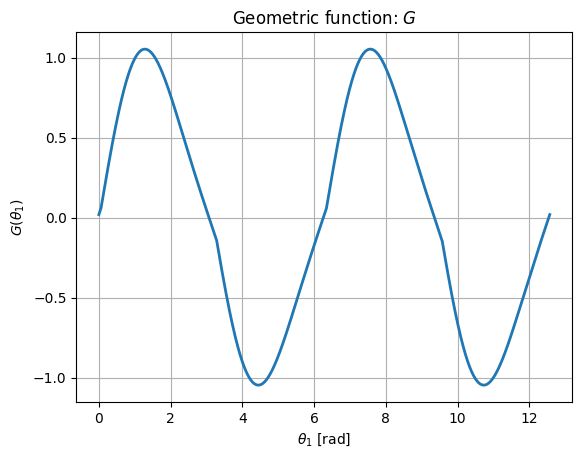

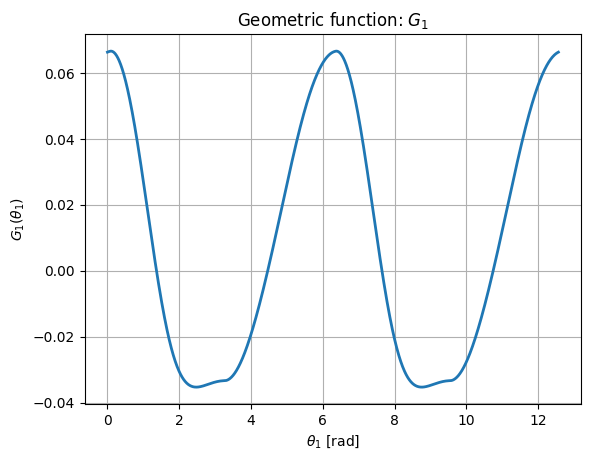

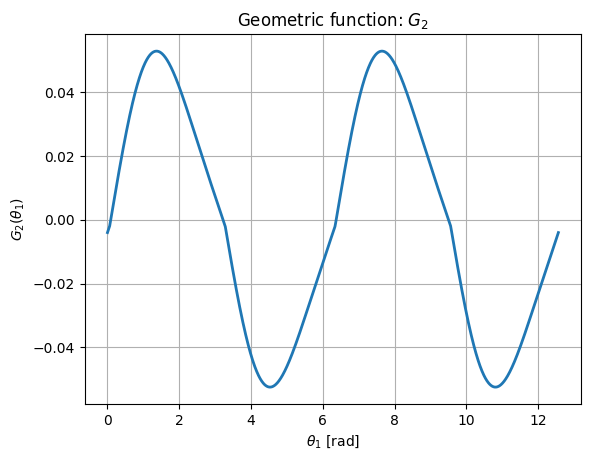

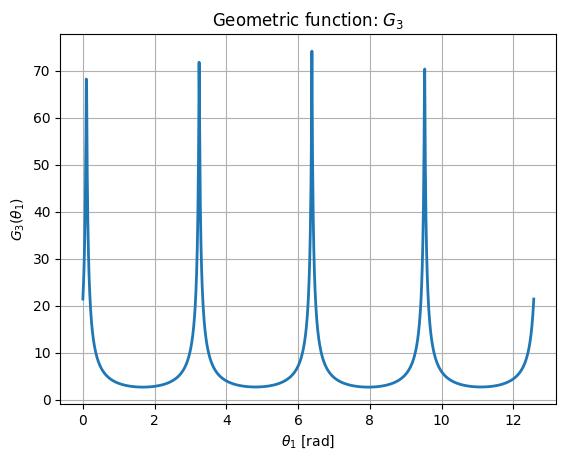

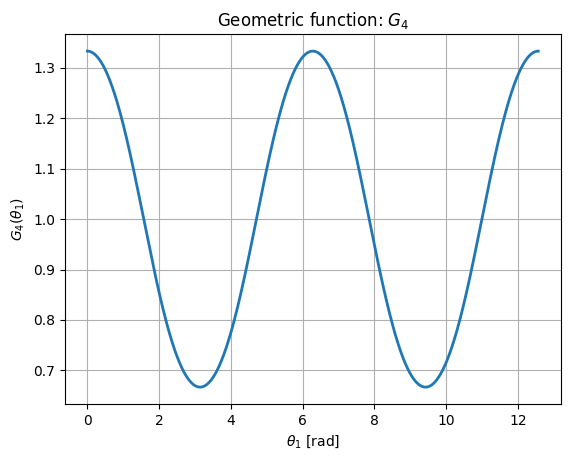

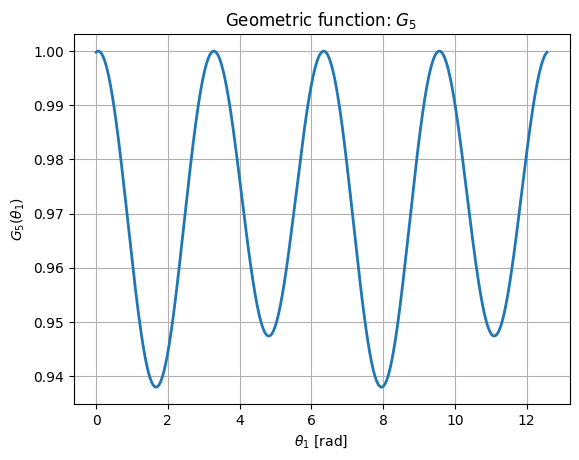

In [480]:

# ----------------------------
# Geometry functions
# ----------------------------

geom_terms = {
    "$G$":  G_array,
    "$G_1$": G1_array,
    "$G_2$": G2_array,
    "$G_3$": G3_array,
    "$G_4$": G4_array,
    "$G_5$": G5_array
}

for name, array in geom_terms.items():
    plt.figure()
    plt.plot(theta1_array, array, linewidth=2)
    plt.title(f'Geometric function: {name}')
    plt.xlabel(r'$\theta_1$ [rad]')
    plt.ylabel(rf'{name}$(\theta_1)$')
    plt.grid(True)

plt.show()

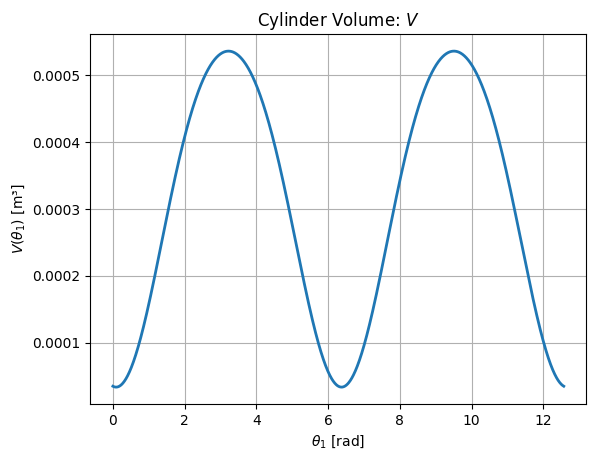

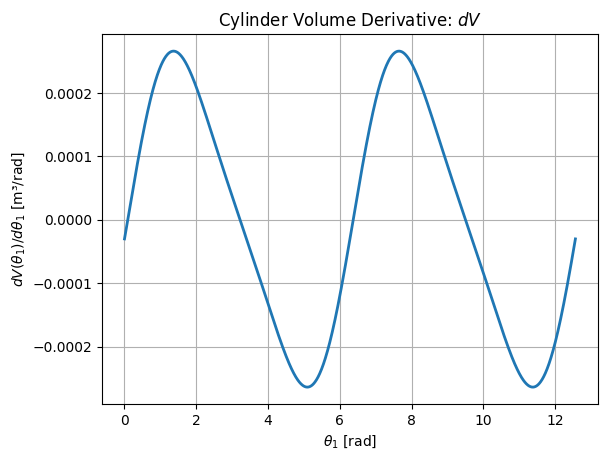

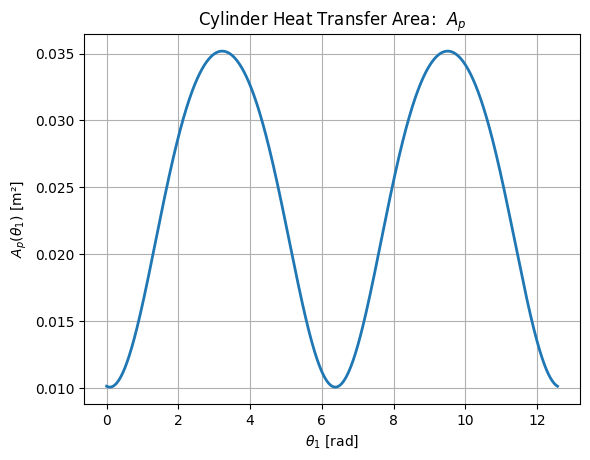

In [481]:

# --------------------------------------
# Cylinder volumes and piston area
# --------------------------------------


# Cylinder volume
plt.figure()
plt.plot(theta1_array, V_array, linewidth=2)
plt.title(r'Cylinder Volume: $V$')
plt.xlabel(r'$\theta_1$ [rad]')
plt.ylabel(r'$V(\theta_1)$ [m³]')
plt.grid(True)

# Cylinder volume derivative
plt.figure()
plt.plot(theta1_array, V_dot_array, linewidth=2)
plt.title(r'Cylinder Volume Derivative: $dV$')
plt.xlabel(r'$\theta_1$ [rad]')
plt.ylabel(r'$dV(\theta_1)/d\theta_1$ [m³/rad]')
plt.grid(True)

# Cylinder heat transfer area
plt.figure()
plt.plot(theta1_array, A_array, linewidth=2)
plt.title(r'Cylinder Heat Transfer Area:  $A_p$')
plt.xlabel(r'$\theta_1$ [rad]')
plt.ylabel(r'$A_p(\theta_1)$ [m²]')
plt.grid(True)

plt.show()

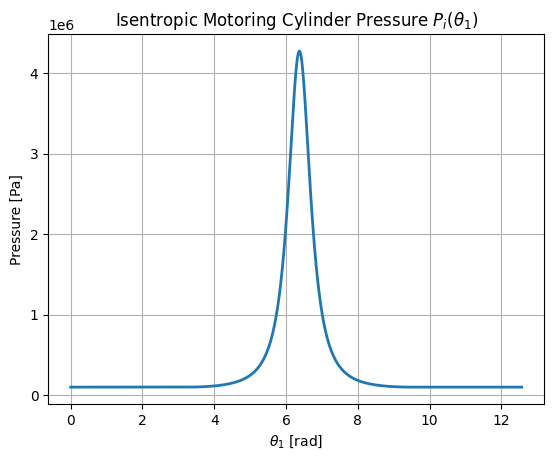

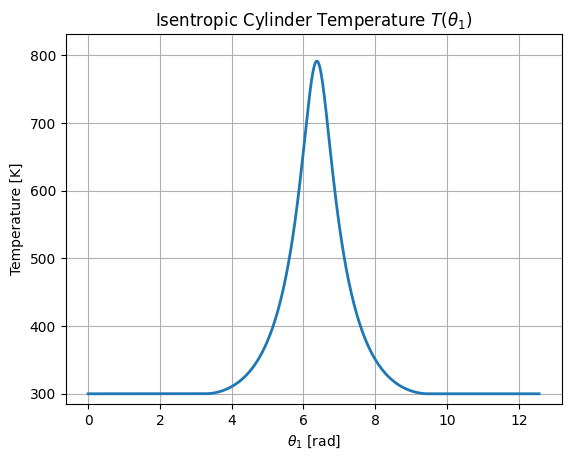

In [482]:

# --------------------------------------
# Isentropic (motoring) pressure
# --------------------------------------

plt.figure()
plt.plot(theta1_array, P_i_array, linewidth=2)
plt.title('Isentropic Motoring Cylinder Pressure $P_i(\\theta_1)$')
plt.xlabel(r'$\theta_1$ [rad]')
plt.ylabel('Pressure [Pa]')
#plt.ylim(3e6, 4.5e6)
plt.grid(True)
plt.show()


# --------------------------------------
# Isentropic (motoring) temperature
# --------------------------------------

plt.figure()
plt.plot(theta1_array, T_temp_array, linewidth=2)
plt.title('Isentropic Cylinder Temperature $T(\\theta_1)$')
plt.xlabel(r'$\theta_1$ [rad]')
plt.ylabel('Temperature [K]')
plt.grid(True)
plt.ylim([T_temp_array.min()*0.95, T_temp_array.max()*1.05])
plt.show()

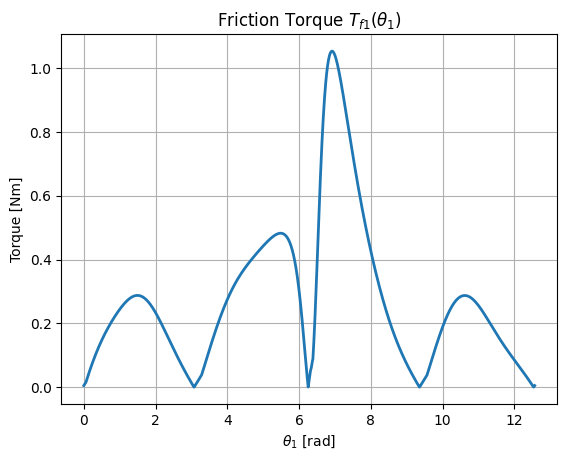

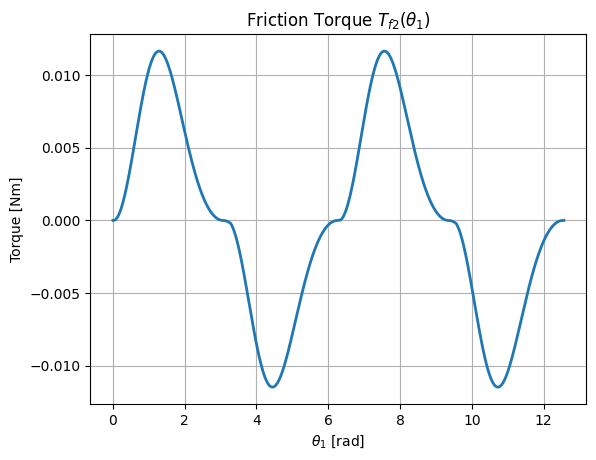

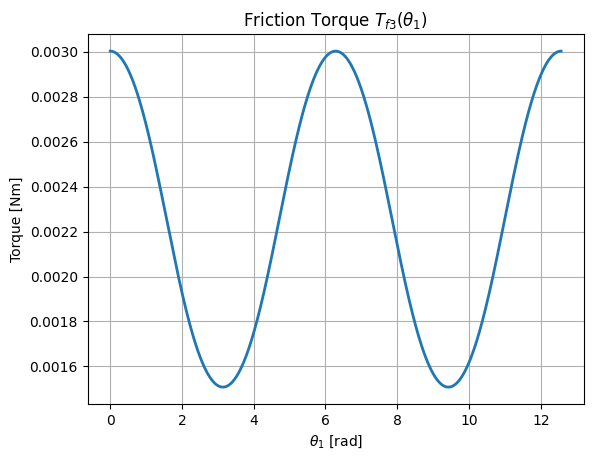

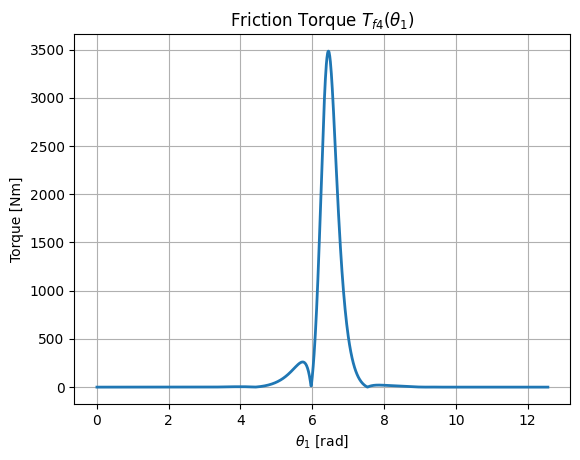

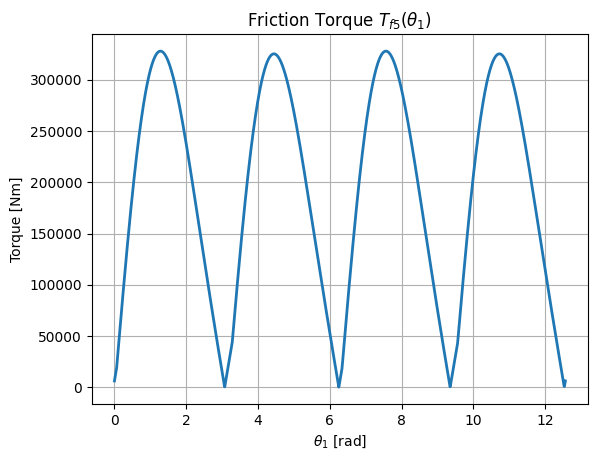

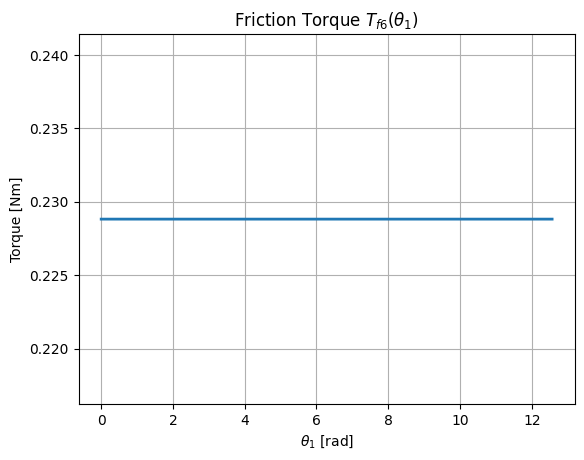

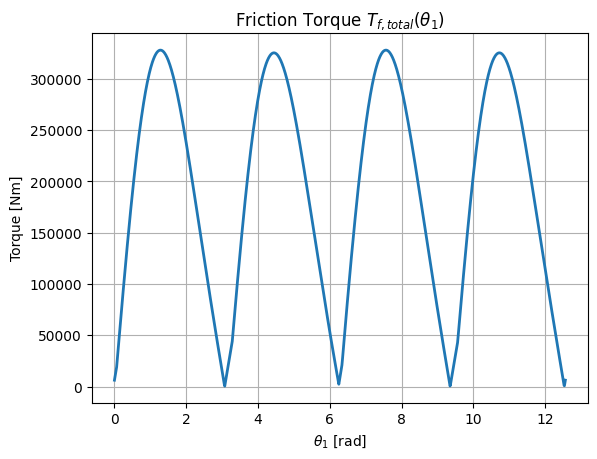

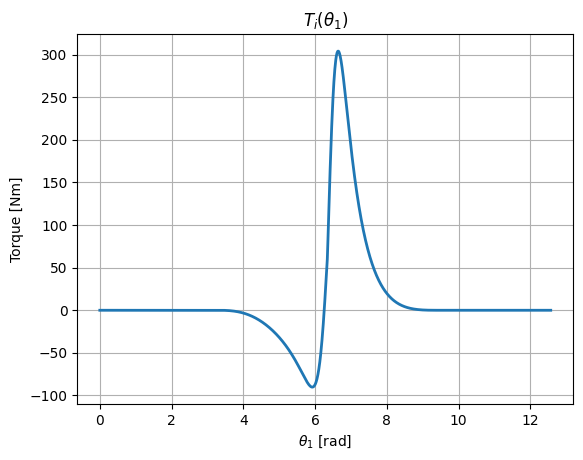

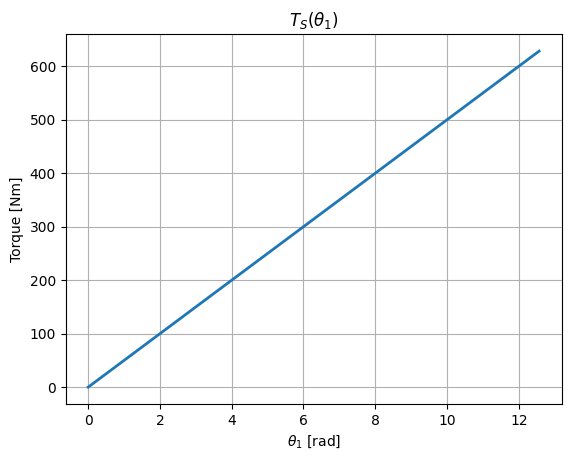

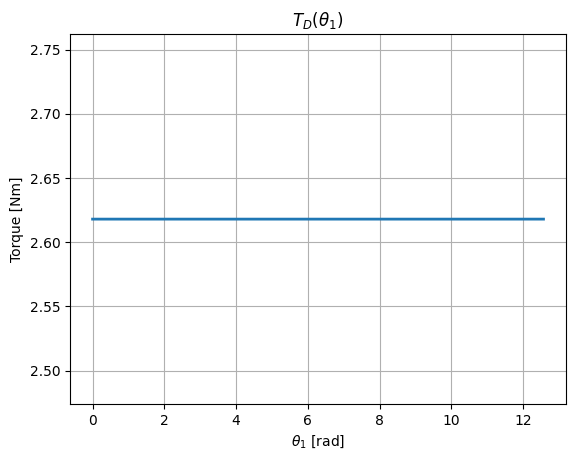

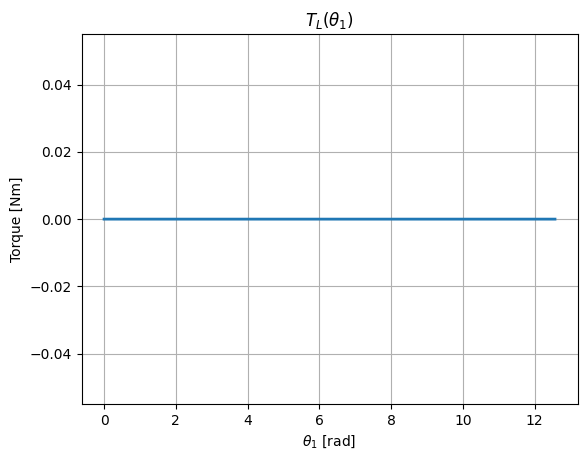

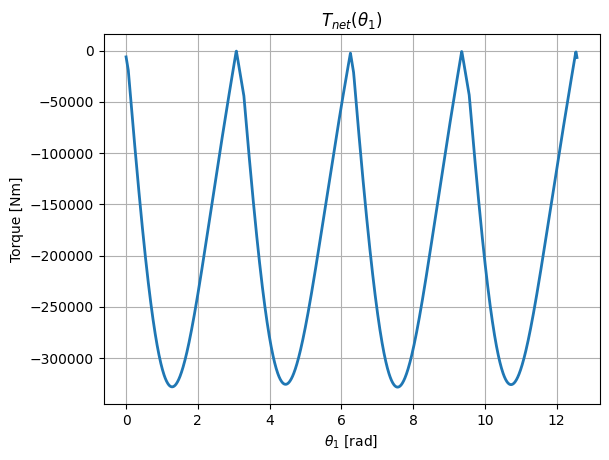

In [483]:
# ----------------------------
# Individual friction torques
# ----------------------------
friction_torques = {
    'T_{f1}': T_f1_array,
    'T_{f2}': T_f2_array,
    'T_{f3}': T_f3_array,
    'T_{f4}': T_f4_array,
    'T_{f5}': T_f5_array,
    'T_{f6}': T_f6_array,
    'T_{f,total}': T_f_total_array
}

for name, array in friction_torques.items():
    plt.figure()
    plt.plot(theta1_array, array, linewidth=2)
    plt.title(f'Friction Torque ${name}(\\theta_1)$')
    plt.xlabel(r'$\theta_1$ [rad]')
    plt.ylabel('Torque [Nm]')
    plt.grid(True)
    plt.show()


# ----------------------------
# Shaft / dynamometer / net torques
# ----------------------------
shaft_torques = {
    'T_i': T_i_array,
    'T_S': T_S_array,
    'T_D': T_D_array,
    'T_L': T_L_array,
    'T_{net}': T_net_array
}

for name, array in shaft_torques.items():
    plt.figure()
    plt.plot(theta1_array, array, linewidth=2)
    plt.title(f'${name}(\\theta_1)$')
    plt.xlabel(r'$\theta_1$ [rad]')
    plt.ylabel('Torque [Nm]')
    plt.grid(True)
    plt.show()

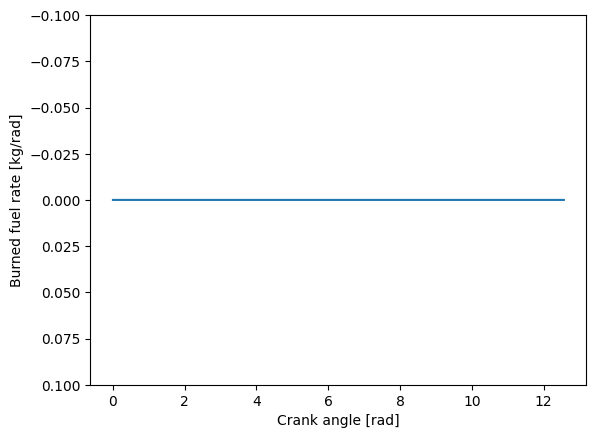

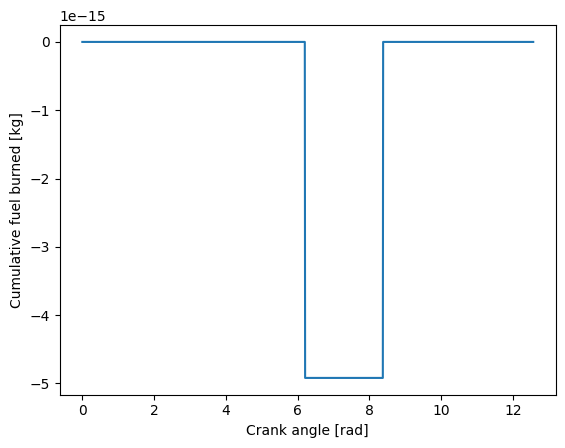

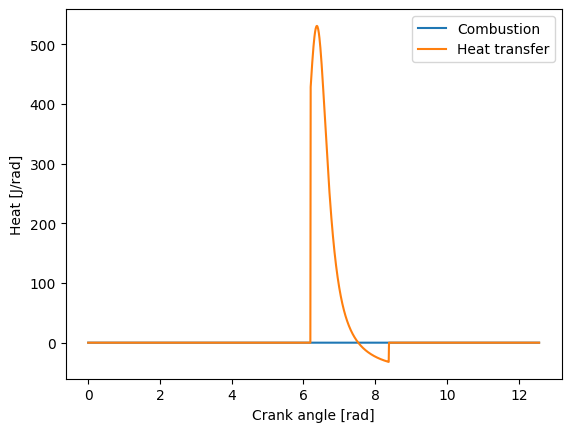

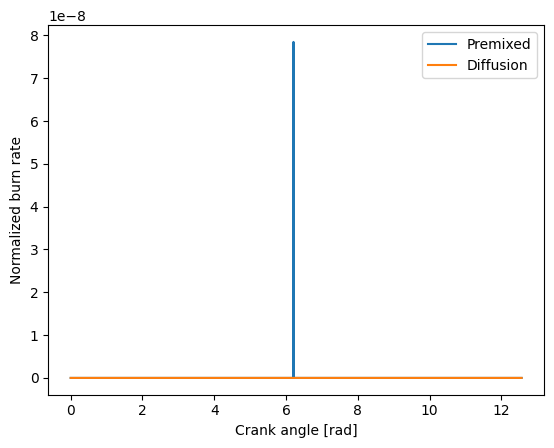

In [500]:
plt.figure()
plt.plot(theta1_array, m_bf_array)
plt.xlabel("Crank angle [rad]")
plt.ylabel("Burned fuel rate [kg/rad]")
plt.ylim(0.1, -0.1)
plt.show()

plt.figure()
plt.plot(theta1_array, m_bf_cum_array)
plt.xlabel("Crank angle [rad]")
plt.ylabel("Cumulative fuel burned [kg]")
plt.show()

plt.figure()
plt.plot(theta1_array, Q_comb_array)
plt.plot(theta1_array, Qht_tot_array)
plt.xlabel("Crank angle [rad]")
plt.ylabel("Heat [J/rad]")
plt.legend(["Combustion", "Heat transfer"])
plt.show()

plt.figure()
plt.plot(theta1_array,  m_fpre_array)
plt.plot(theta1_array, m_fdiff_array)
plt.xlabel("Crank angle [rad]")
plt.ylabel("Normalized burn rate")
plt.legend(["Premixed", "Diffusion"])
plt.show()

. \
.

.

.

.

## References

[1] <a id="zweiri2001"></a>
   Zweiri, Y. H., J. F. Whidborne, and L. D. Seneviratne. "Detailed analytical model of a single-cylinder diesel engine in the crank angle
   domain." Proceedings of the Institution of Mechanical Engineers, Part D: Journal of Automobile Engineering 215.11 (2001): 1197-1216.